In [1]:
import xarray as xr
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
#import statsmodels.api as sm
#from cmap import Colormap
import seaborn as sns
from scipy import stats
from string import ascii_lowercase, ascii_uppercase


/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [3]:
rootpath = Path('/sto0/data/Intermediate/Hunga_Tonga_byAles/')
inpath = rootpath / 'data'
xr.set_options(keep_attrs=True)
plt.rcParams.update({"font.size": 22})

In [4]:
def anomalize(ds, how = 'dayofyear'):
    clim = ds.sel(time = slice('2006','2020')).groupby(f'time.{how}').mean()
    anom = (ds.groupby(f'time.{how}')-clim).load()
    return anom, clim

def rfilter(da):
    weight = xr.DataArray([0.1, 0.25, 0.5, 0.25, 0.1], dims=["y"])

    return da.rolling(pressure = 5, center = True, min_periods = 3).construct(pressure = 'y').dot(weight)

In [175]:
ds_h2o_cor = xr.open_dataset('2024-10-01_to_2025-04-01_MLS-Aura_L2GP-H2O_v05.03_smoothedwAK_qs_minimal_2.5x360_lat_lon.nc')
ds_h2o_cor

<xarray.Dataset> Size: 3MB
Dimensions:        (latitude_bins: 72, time: 183, pressure: 55)
Coordinates:
  * pressure       (pressure) float32 220B 1e+03 825.4 681.3 ... 2.154e-05 1e-05
  * time           (time) datetime64[ns] 1kB 2024-10-01 ... 2025-04-01
  * latitude_bins  (latitude_bins) float64 576B -88.75 -86.25 ... 86.25 88.75
Data variables:
    h2o            (latitude_bins, time, pressure) float32 3MB ...

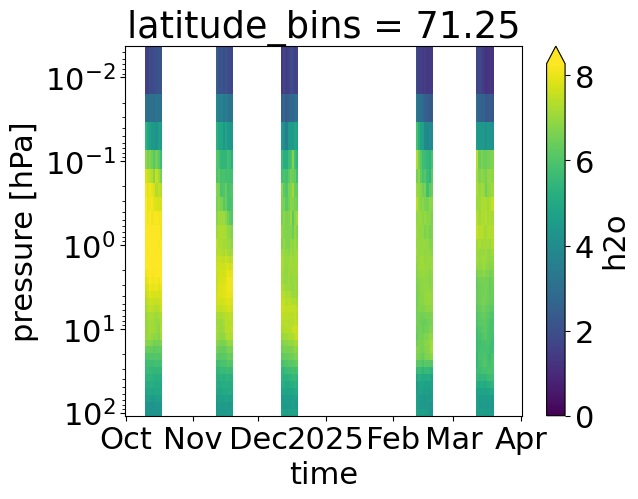

In [184]:
ds_h2o_cor['h2o'].sel(latitude_bins = 70, method = 'nearest').sel(pressure = slice(100,0.01)).plot(x = 'time', yincrease = False, vmin =0, robust = True)
plt.yscale('log')

In [397]:
ds_h2o_cor['h2o'].sel(latitude_bins = 70,method = 'nearest').sel(pressure = slice(100,0.01), time = slice('2024-12-01','2024-12-31'))

<xarray.DataArray 'h2o' (time: 31, pressure: 34)> Size: 4kB
[1054 values with dtype=float32]
Coordinates:
  * pressure       (pressure) float32 136B 100.0 82.54 68.13 ... 0.02154 0.01
  * time           (time) datetime64[ns] 248B 2024-12-01 ... 2024-12-31
    latitude_bins  float64 8B 71.25

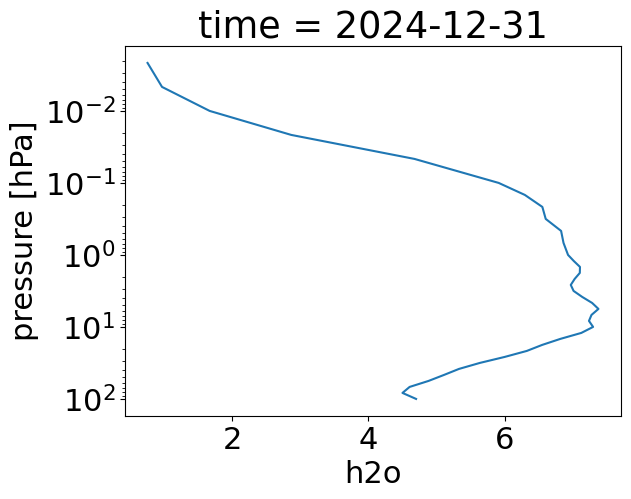

In [416]:
ds_h2o_cor['h2o'].resample(time = '1M').mean().sel(latitude_bins = slice(60,None), pressure = slice(100,None)).weighted(weights).mean('latitude_bins')[2].plot(y = 'pressure', yincrease = False)
plt.yscale('log')

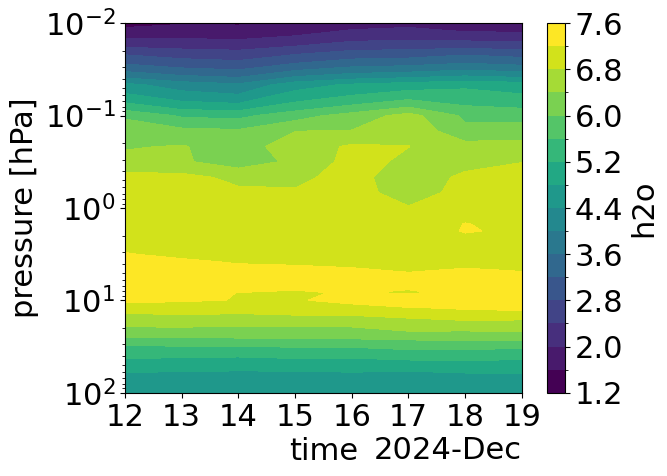

In [431]:
ds_h2o_cor['h2o'].sel(latitude_bins = slice(60,None), time = slice('2024-12-12','2024-12-19'), pressure = slice(100,0.01)).weighted(weights).mean(['latitude_bins']).plot.contourf(y = 'pressure', yincrease = False, levels = 21)
plt.yscale('log')

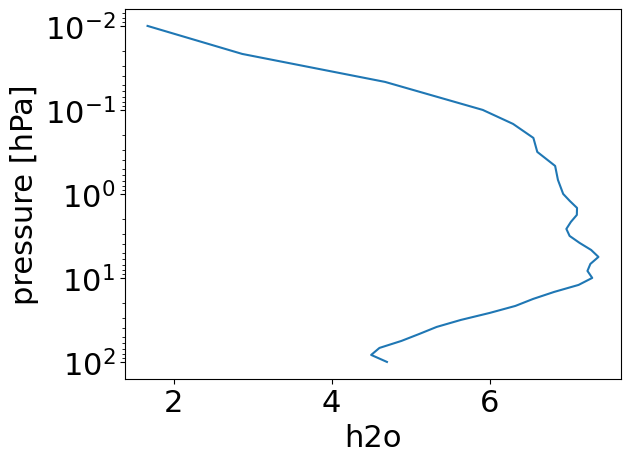

In [434]:
ds_h2o_cor['h2o'].sel(latitude_bins = slice(60,None), time = slice('2024-12-12','2024-12-19'), pressure = slice(100,0.01)).weighted(weights).mean(['latitude_bins','time']).plot(y = 'pressure', yincrease = False)
plt.yscale('log')

In [ ]:
ds_h2o_cor['h2o'][60:90].sel(latitude_bins = slice(60,None), pressure = slice(100,None)).weighted(weights).mean('latitude_bins')[2].plot(y = 'pressure', yincrease = False)
plt.yscale('log')

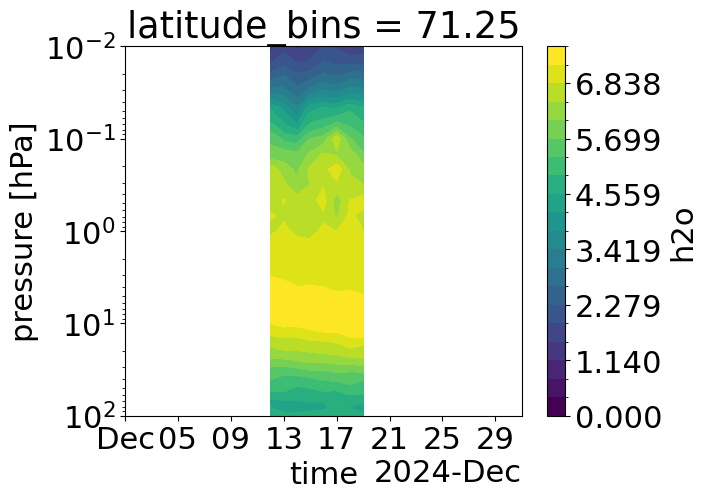

In [219]:
ds_h2o_cor['h2o'].sel(latitude_bins = 70,method = 'nearest').sel(pressure = slice(100,0.01), time = slice('2024-12-01','2024-12-31')).plot.contourf(x = 'time', yincrease = False, vmin =0, robust = False, levels = 21)
plt.yscale('log')

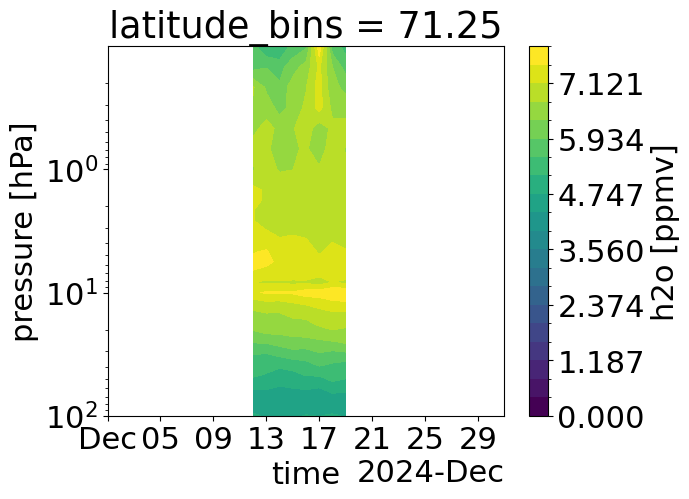

In [218]:
ds['h2o'].sel(latitude_bins = 70,method = 'nearest').sel(pressure = slice(100,0.1), time = slice('2024-12-01','2024-12-31')).plot.contourf(x = 'time', yincrease = False, vmin =0, robust = False, levels = 21)
plt.yscale('log')

In [4]:
inpath = rootpath / 'stocker' / 'for_ales' / '2006-01-01_to_2025-03-17_MLS_v05_qs_h2o_mass_global_100hPa-1hPa.nc'
ds_h2o = xr.open_dataset(inpath)
ds_h2o

<xarray.Dataset> Size: 112kB
Dimensions:   (time: 7016)
Coordinates:
  * time      (time) datetime64[ns] 56kB 2006-01-01 2006-01-02 ... 2025-03-17
Data variables:
    H2O_mass  (time) float64 56kB ...

In [5]:
infiles = sorted((rootpath / 'stocker' / 'data'  ).glob('*.nc'))
infiles = sorted((rootpath / 'stocker' / 'MLSv6' / 'Update_202604' ).glob('*.nc'))
msl_suffix = 'v6'
infiles

[PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/stocker/MLSv6/Update_202604/2004-08-02_to_2026-04-02_MLS-Aura_L2GP-H2O_v06_qs_2.5x360_lat_lon.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/stocker/MLSv6/Update_202604/2004-08-02_to_2026-04-02_MLS-Aura_L2GP-O3_v06_qs_2.5x360_lat_lon.nc'),
 PosixPath('/sto0/data/Intermediate/Hunga_Tonga_byAles/stocker/MLSv6/Update_202604/2004-08-02_to_2026-04-02_MLS-Aura_L2GP-Temperature_v06_qs_2.5x360_lat_lon.nc')]

In [6]:
#infile = inpath / '2005-01-01_to_2025-04-30_MLS-Aura_L2GP-Temperature_v05_qs_2.5x360_lat_lon.nc'
#ds = xr.open_dataset(infile)
ds  = xr.open_mfdataset(infiles, parallel=True, combine = 'nested')
ds

<xarray.Dataset> Size: 376MB
Dimensions:        (latitude_bins: 72, time: 7914, pressure: 55)
Coordinates:
  * latitude_bins  (latitude_bins) float64 576B -88.75 -86.25 ... 86.25 88.75
  * time           (time) datetime64[ns] 63kB 2004-08-02 ... 2026-04-02
  * pressure       (pressure) float32 220B 1e+03 825.4 681.3 ... 2.154e-05 1e-05
Data variables:
    h2o            (latitude_bins, time, pressure) float32 125MB dask.array<chunksize=(72, 7914, 55), meta=np.ndarray>
    O3             (latitude_bins, time, pressure) float32 125MB dask.array<chunksize=(72, 7914, 55), meta=np.ndarray>
    temperature    (latitude_bins, time, pressure) float32 125MB dask.array<chunksize=(72, 7914, 55), meta=np.ndarray>
Attributes:
    title:    Aura MLS v6.01 Level-2 data product
    history:  Postprocessed by WEGC; screened using MLS precision estimates a...

In [8]:
weights = np.cos(np.deg2rad(ds.latitude_bins))


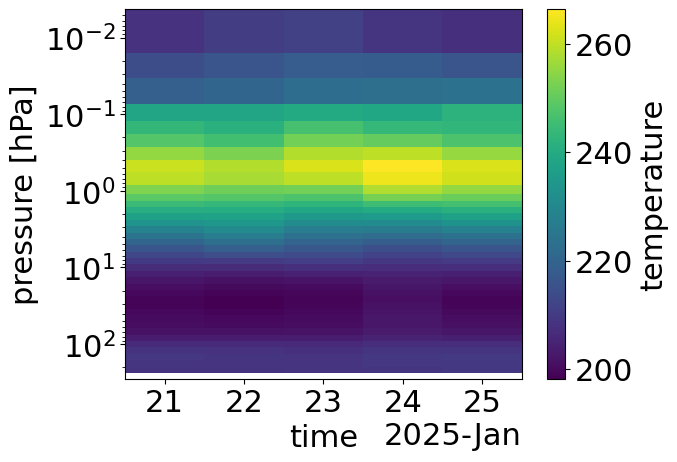

In [9]:
ds['temperature'].sel(
    time = slice('2025-01-21','2025-01-25'),
    latitude_bins = slice(60,90),
    pressure = slice(300,0.01),
).weighted(weights).mean('latitude_bins').plot(x = 'time', yincrease = False)
plt.yscale('log')

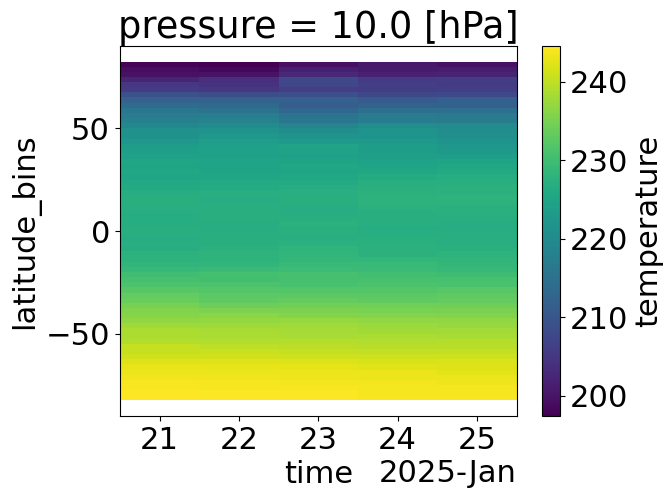

In [10]:
ds['temperature'].sel(
    time = slice('2025-01-21','2025-01-25'),
    #latitude_bins = slice(60,90),
    pressure = 10,
).plot(x = 'time')

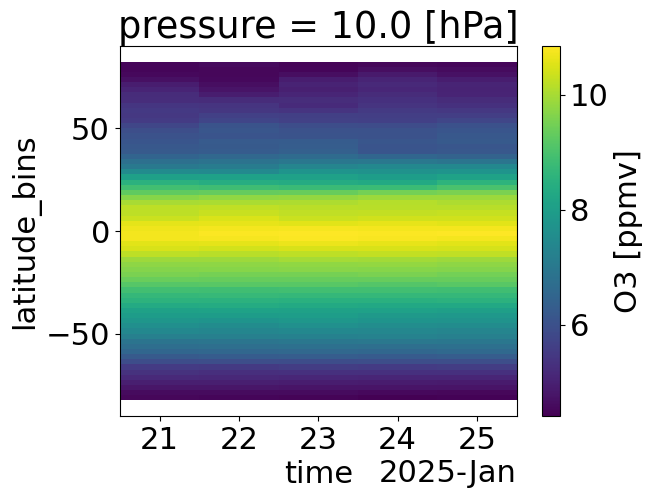

In [11]:
ds['O3'].sel(
    time = slice('2025-01-21','2025-01-25'),
    #latitude_bins = slice(60,90),
    pressure = 10,
).plot(x = 'time')

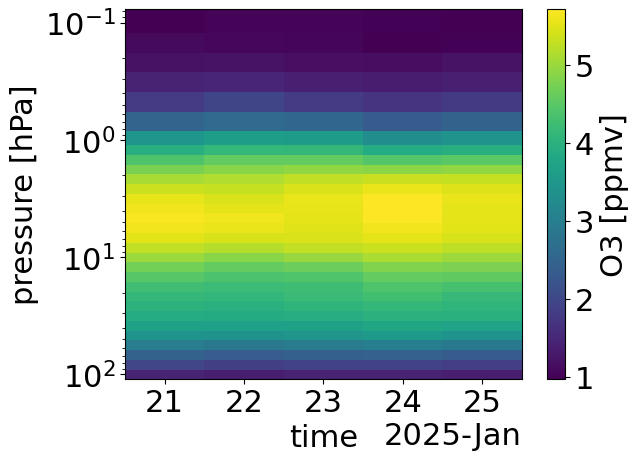

In [12]:
ds['O3'].sel(
    time = slice('2025-01-21','2025-01-25'),
    latitude_bins = slice(60,90),
    pressure = slice(100,0.1),
).weighted(weights).mean('latitude_bins').plot(x = 'time', yincrease = False)
plt.yscale('log')

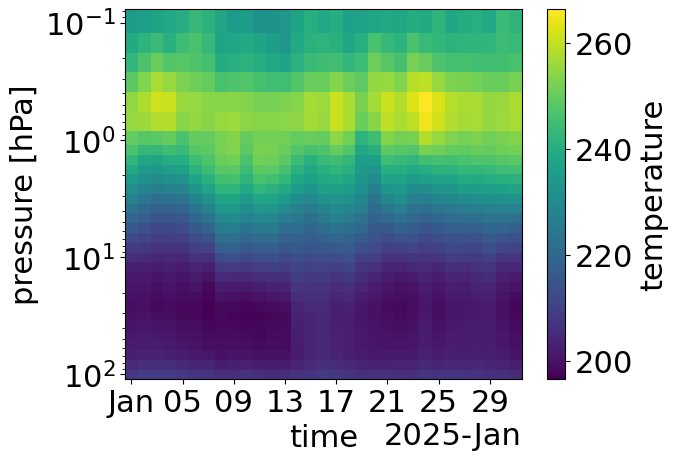

In [14]:
ds['temperature'].sel(
    time = '2025-01',
    latitude_bins = slice(60,90),
    pressure = slice(100,0.1),
).weighted(weights).mean('latitude_bins').plot(x = 'time', yincrease = False)
plt.yscale('log')

In [7]:
da_t = ds['temperature']
anom_doy, clim_doy = anomalize(ds)
anom_mon, clim_mon = anomalize(ds, how = 'month')

In [16]:
clim_mon_new = clim_mon.copy()
clim_mon_new = clim_mon_new.rename({'month': 'dayofyear'})
# https://chatgpt.com/share/68e516e4-8478-8006-8baf-dfdd98ef98fe
clim_mon_new['dayofyear'] = [16, 45, 74, 105, 135, 166, 196, 227, 258, 289, 319, 350]
clim_mon_new = clim_mon_new.interp(dayofyear = np.arange(1,367), kwargs={"fill_value": "extrapolate"})
anom_int = (ds.groupby(f'time.dayofyear')-clim_mon_new).load()
#h2o_anom_int = (ds_h2o_cor['h2o'].groupby(f'time.dayofyear')-clim_mon_new['h2o']).load()

#ds_h2o_cor_r = rfilter(ds_h2o_cor['h2o'].resample(time = '1M').mean())
#h2o_anom_int_mon = (ds_h2o_cor_r.groupby(f'time.month')-rfilter(clim_mon['h2o'])).load()

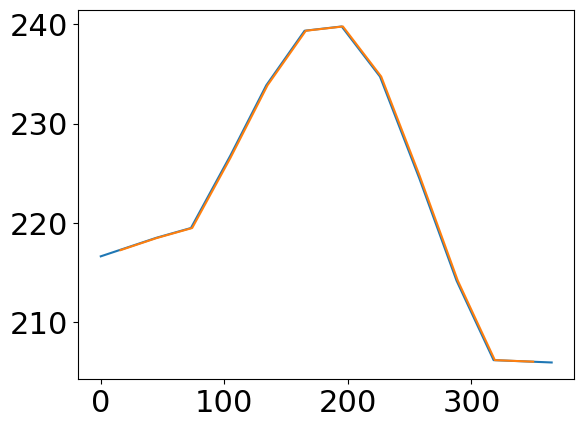

In [55]:
plt.plot(clim_mon_new['temperature'].sel(
    latitude_bins = slice(60,None), pressure = 10).weighted(weights).mean('latitude_bins').values)
plt.plot([16, 45, 74, 105, 135, 166, 196, 227, 258, 289, 319, 350],clim_mon['temperature'].sel(
    latitude_bins = slice(60,None), pressure = 10).weighted(weights).mean('latitude_bins').values)

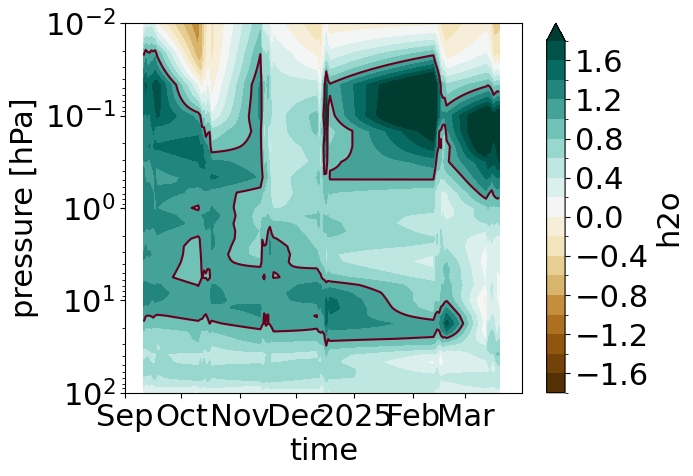

In [39]:
temp2 = anom_int.sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month-1:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
temp2 = temp2.interpolate_na(dim = 'time')
temp2['h2o'].sel(pressure = slice(100,0.01)).plot.contourf(x = 'time', yincrease = False, center =0, robust = True, levels = 21, cmap = 'BrBG')
temp2['h2o'].sel(pressure = slice(100,0.01)).plot.contour(x = 'time', yincrease = False, levels=[1])
plt.yscale('log')

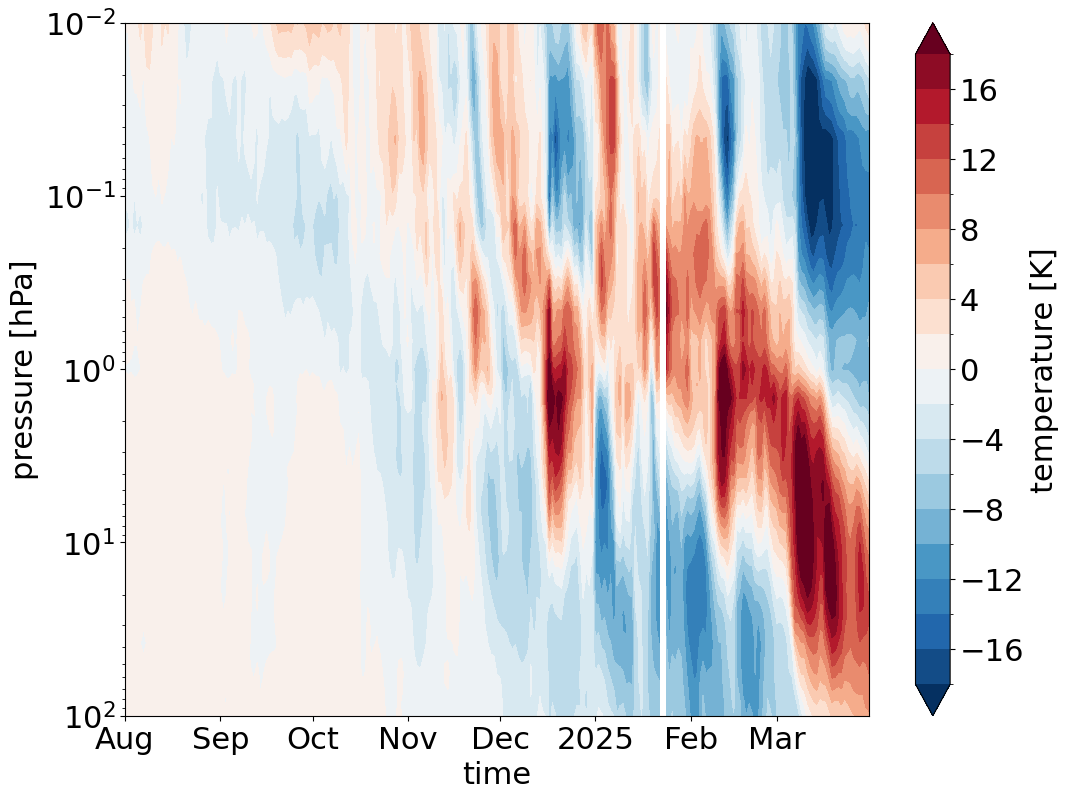

In [58]:
temp2 = anom_int.sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month-2:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
#temp2 = temp2.interpolate_na(dim = 'time')
temp2['temperature'].sel(pressure = slice(100,0.01)).plot.contourf(x = 'time', yincrease = False, center =0, robust = True, levels = 21, cmap = 'RdBu_r', size = 9)
plt.yscale('log')

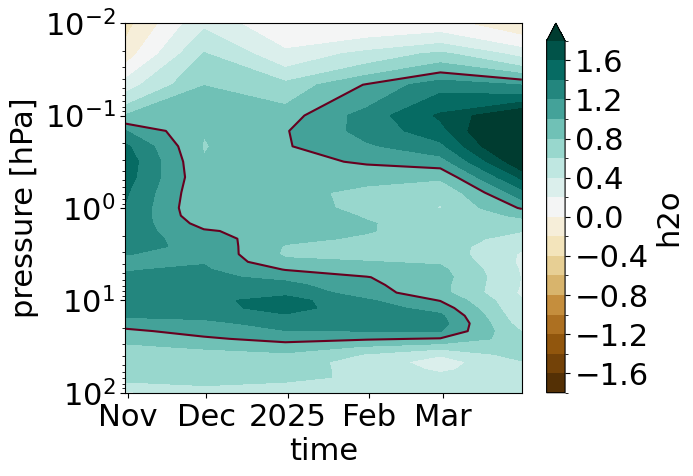

In [457]:
temp2 = h2o_anom_int_mon.sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month-1:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
temp2 = temp2.interpolate_na(dim = 'time')
temp2.sel(pressure = slice(100,0.01)).plot.contourf(x = 'time', yincrease = False, center =0, robust = True, levels = 21, cmap = 'BrBG')
temp2.sel(pressure = slice(100,0.01)).plot.contour(x = 'time', yincrease = False, levels=[1])
plt.yscale('log')

In [9]:
#ds_h2o_cor_r = rfilter(ds['h2o'].resample(time = '1M').mean())
ds_h2o_cor_r =ds['h2o'].resample(time = '1M').mean()
#h2o_anom_int_mon = (ds_h2o_cor_r.groupby(f'time.month')-rfilter(clim_mon['h2o'])).load()
h2o_anom_int_mon = (ds_h2o_cor_r.groupby(f'time.month')-clim_mon['h2o']).load()

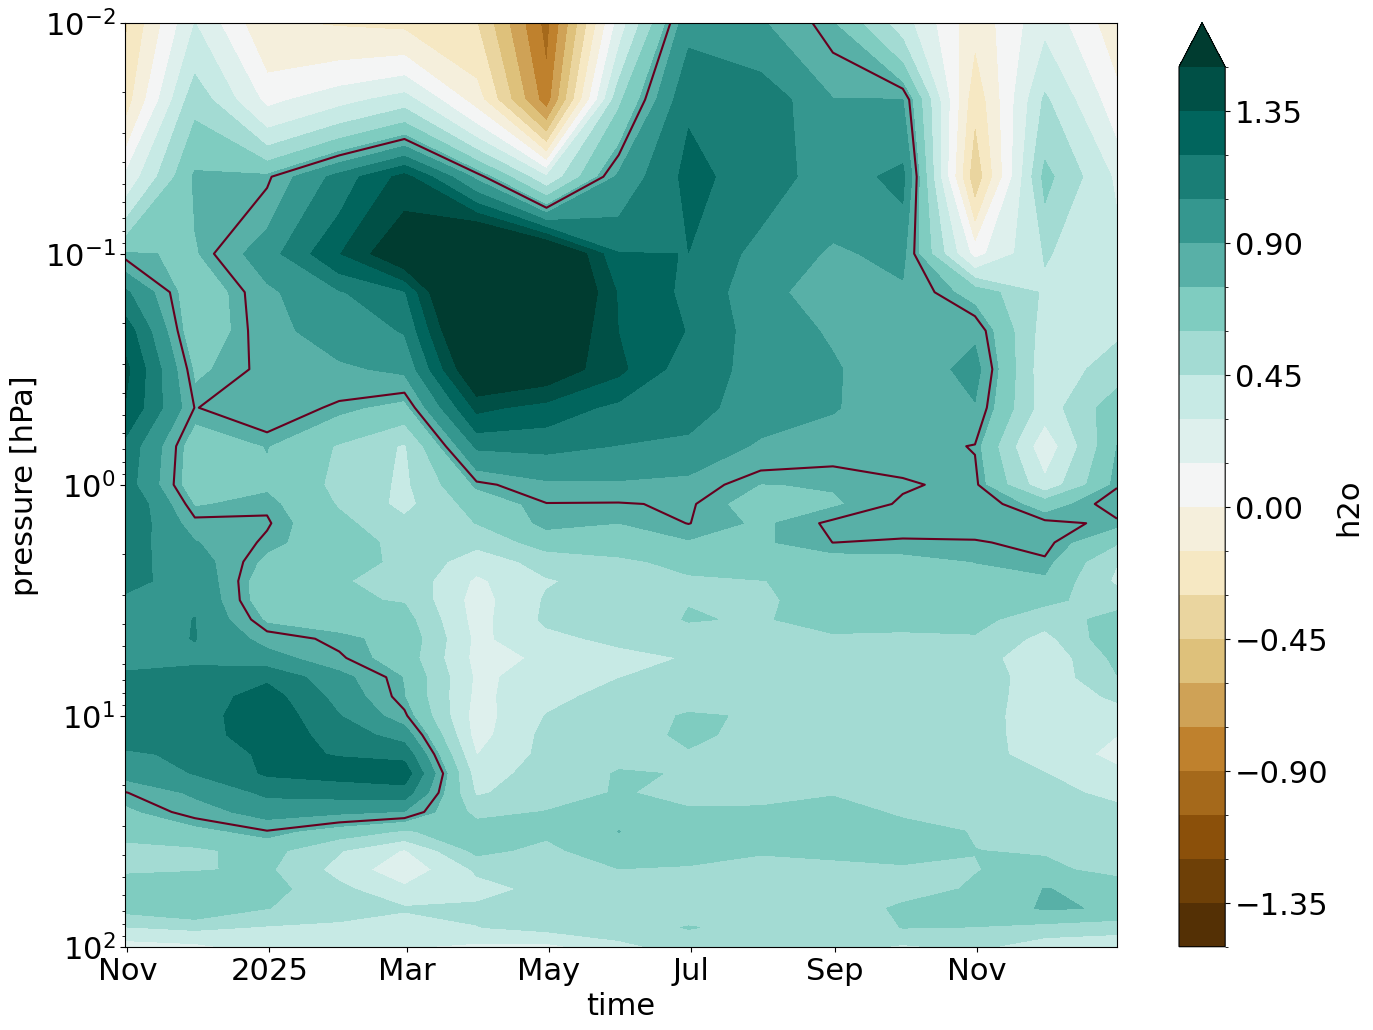

In [15]:
pres_start = 100
pres_end = 0.01
s_year = '2024'
s_month = 11
time_end = '2025-12'


weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"

temp2 = h2o_anom_int_mon.sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month-1:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
temp2 = temp2.interpolate_na(dim = 'time')
temp2.sel(pressure = slice(100,0.01)).plot.contourf(x = 'time', yincrease = False, center =0, robust = True, levels = 21, cmap = 'BrBG', size = 12)
temp2.sel(pressure = slice(100,0.01)).plot.contour(x = 'time', yincrease = False, levels=[0.8])
plt.yscale('log')

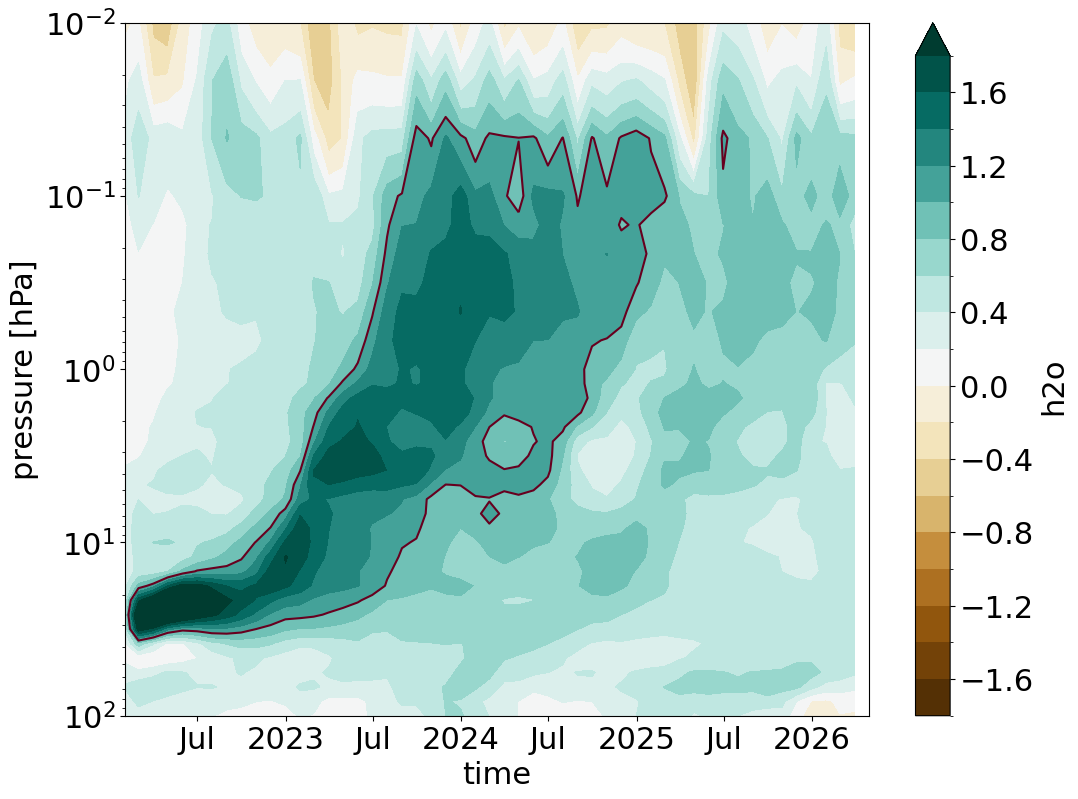

In [23]:
pres_start = 100
pres_end = 0.01
s_year = '2022'
s_month = 2
time_end = None


weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"

temp2 = h2o_anom_int_mon.sel(
    time = slice(f'{s_year}-{s_month-1:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
temp2 = temp2.interpolate_na(dim = 'time')
temp2.sel(pressure = slice(100,0.01)).plot.contourf(x = 'time', yincrease = False, center =0, robust = True, levels = 21, cmap = 'BrBG', size = 9)
temp2.sel(pressure = slice(100,0.01)).plot.contour(x = 'time', yincrease = False, levels=[1])
plt.yscale('log')

In [24]:
outfile = rootpath / 'MLSv6_H2O_202201-2025-11_non-smoothed.nc'
print(outfile)
temp2.to_netcdf(outfile)

/sto0/data/Intermediate/Hunga_Tonga_byAles/MLSv6_H2O_202201-2025-11_non-smoothed.nc


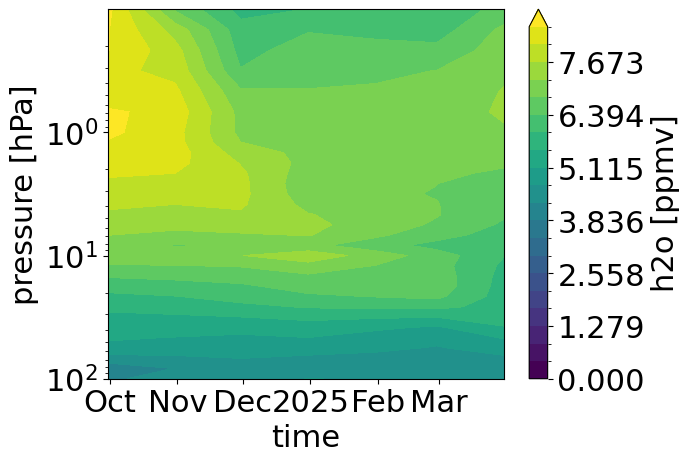

In [437]:
temp2 = ds['h2o'].sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month-1:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
temp2 = temp2.resample(time = '1M').mean().interpolate_na(dim = 'time')
temp2.sel(pressure = slice(100,0.1)).plot.contourf(x = 'time', yincrease = False, vmin =0, robust = True, levels = 21)
plt.yscale('log')

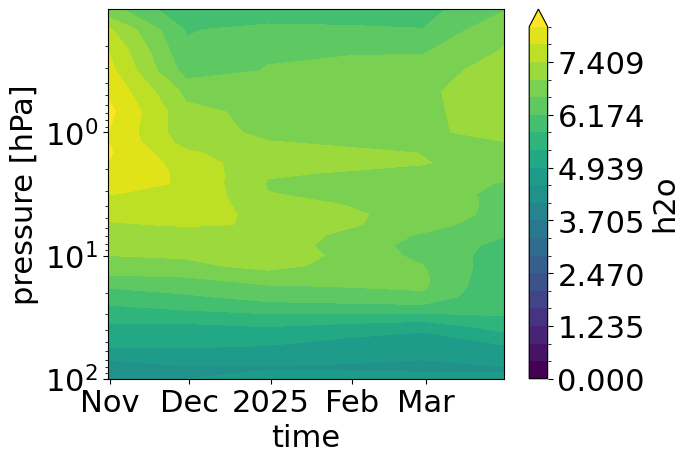

In [259]:
temp = ds_h2o_cor['h2o'].sel(
    latitude_bins = slice(60,None),
    time = slice(f'{s_year}-{s_month-1:02d}', time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
temp = temp.resample(time = '1M').mean().interpolate_na(dim = 'time')
temp.sel(pressure = slice(100,0.1)).plot.contourf(x = 'time', yincrease = False, vmin =0, robust = True, levels = 21)
plt.yscale('log')

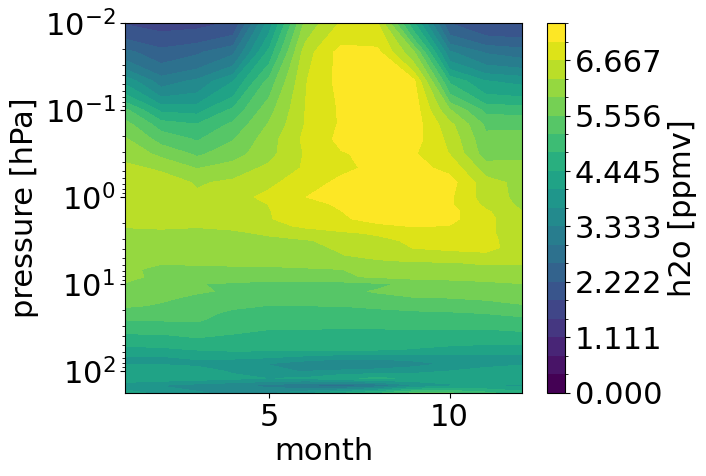

In [249]:
clim_mon['h2o'].sel(
    latitude_bins = slice(60,None),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins').plot.contourf(x = 'month', yincrease = False, robust = False, levels = 21, vmin = 0)
plt.yscale('log')

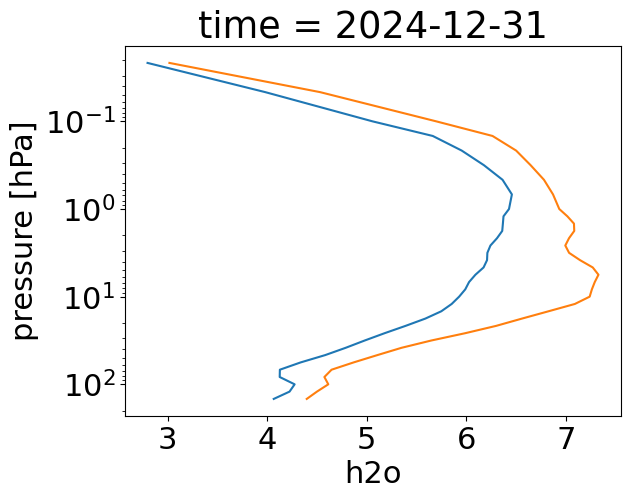

In [436]:
temp_clim = clim_mon['h2o'].sel(
    latitude_bins = slice(60,None),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
rfilter(temp_clim)[0].plot(y = 'pressure', yincrease = False)
rfilter(temp[2]).plot(y = 'pressure', yincrease = False)
#temp2[4].plot(y = 'pressure', yincrease = False)

plt.yscale('log')

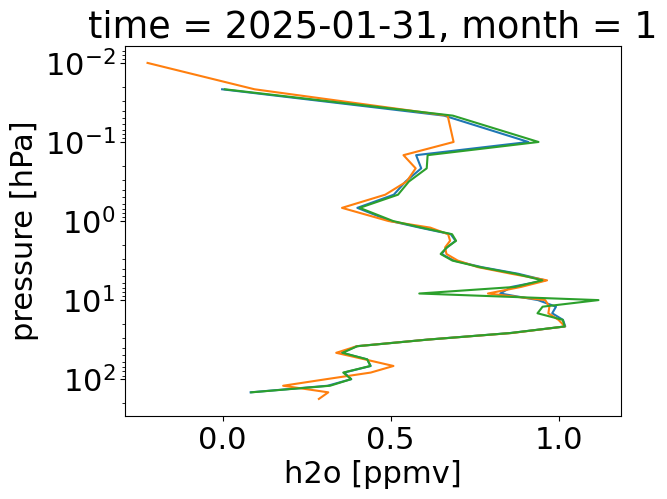

In [307]:
temp_clim = clim_mon['h2o'].sel(
    latitude_bins = slice(60,None),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
weight = xr.DataArray([0.25, 0.5, 0.25], dims=["y"])
(temp[3]-temp_clim.rolling(pressure = 3, center = True).construct(pressure = 'y').dot(weight)[0]).plot(y = 'pressure', yincrease = False)
(temp[3]-temp_clim[0]).plot(y = 'pressure', yincrease = False)
(temp2[4]-temp_clim.rolling(pressure = 3, center = True).construct(pressure = 'y').dot(weight)[0]).plot(y = 'pressure', yincrease = False)


plt.yscale('log')

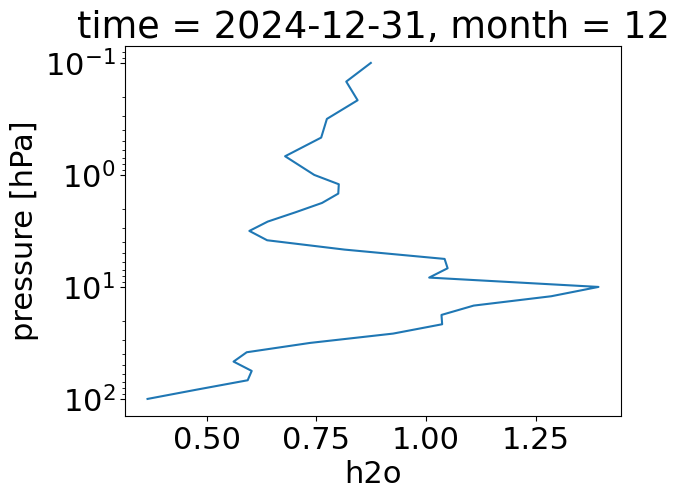

In [264]:
anom_temp.sel(pressure = slice(100,0.1))[2].plot(y = 'pressure', yincrease = False)
plt.yscale('log')

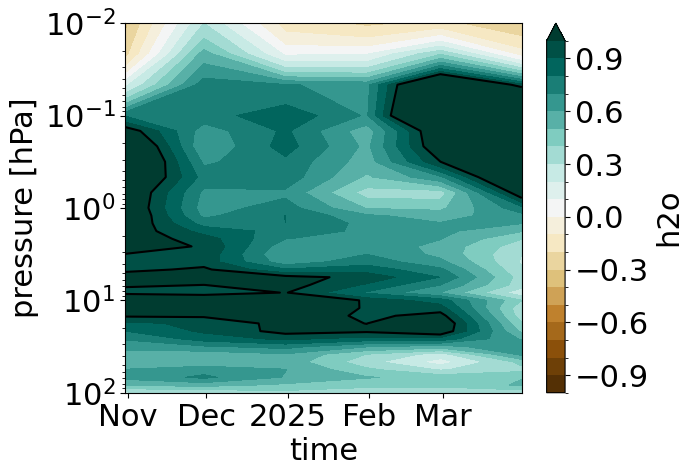

In [274]:
anom_temp = temp.groupby('time.month')-clim_mon['h2o'].sel(
    latitude_bins = slice(60,None),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')
anom_temp.sel(pressure = slice(100,0.01)).plot.contourf(x = 'time', yincrease = False, center =0, robust = True, levels = 21, vmin = -1, vmax = 1, cmap = 'BrBG')
anom_temp.sel(pressure = slice(100,0.01)).plot.contour(x = 'time', yincrease = False, levels=[1], colors = 'k')
plt.yscale('log')

In [ ]:
anom_temp.rolling(pressure = 3, center=True, min_periods=1).mean().sel(pressure = slice(100,0.01)).plot.contourf(x = 'time', yincrease = False, center =0, robust = True, levels = 21, vmin = -1, vmax = 1, cmap = 'BrBG')
plt.yscale('log')

In [299]:
kernel

<xarray.DataArray (x: 3, y: 2)> Size: 48B
array([[1., 0.],
       [1., 1.],
       [1., 0.]])
Dimensions without coordinates: x, y

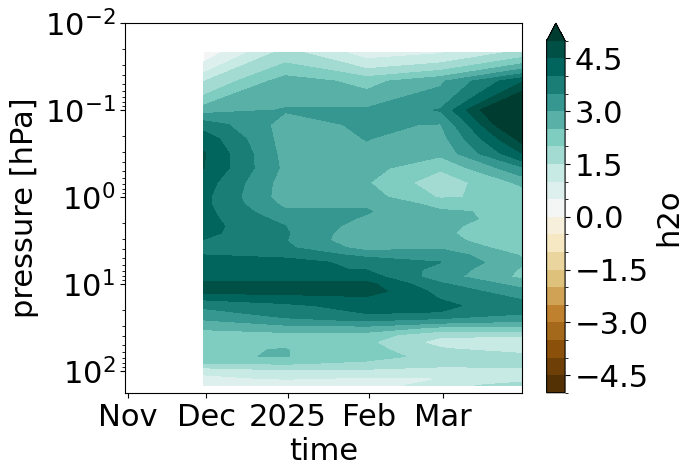

In [300]:
kernel_np = np.array([[0., 1., 0.],
       [1., 1., 1.],
       [0., 1., 0.]])
kernel_np = np.array([[1., 0.],
       [1., 1,],
       [1, 0,]])
kernel = xr.DataArray(kernel_np.T, dims=['x', 'y']) 
r = anom_temp.load().rolling(time=2, pressure=3, center=True)
r.construct(time="x", pressure="y").dot(kernel).plot.contourf(x = 'time', yincrease = False, center =0, robust = True, levels = 21, cmap = 'BrBG')
plt.yscale('log')

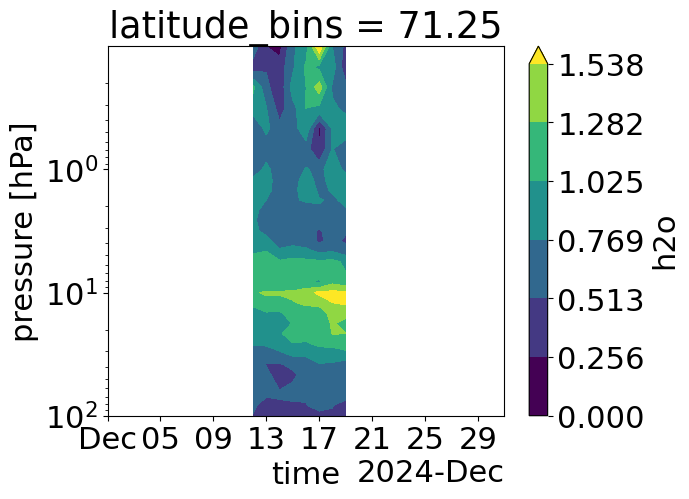

In [265]:
h2o_anom_int_mon.sel(latitude_bins = 70,method = 'nearest').sel(pressure = slice(100,0.1), time = slice('2024-12-01','2024-12-31')).plot.contourf(x = 'time', yincrease = False, vmin =0, robust = True)
plt.yscale('log')

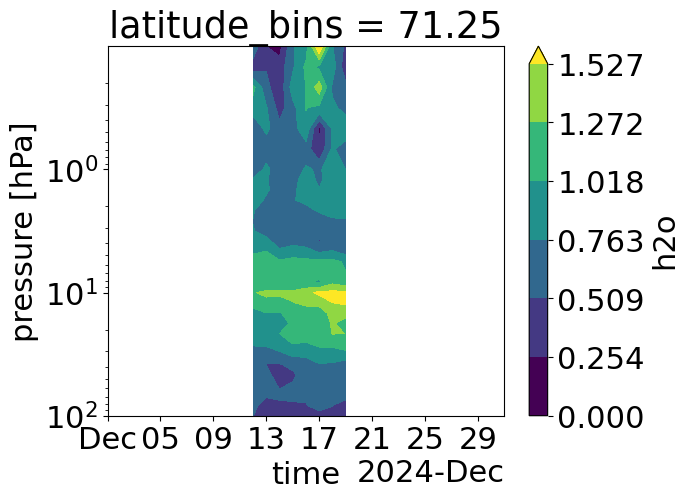

In [221]:
h2o_anom_int.sel(latitude_bins = 70,method = 'nearest').sel(pressure = slice(100,0.1), time = slice('2024-12-01','2024-12-31')).plot.contourf(x = 'time', yincrease = False, vmin =0, robust = True)
plt.yscale('log')

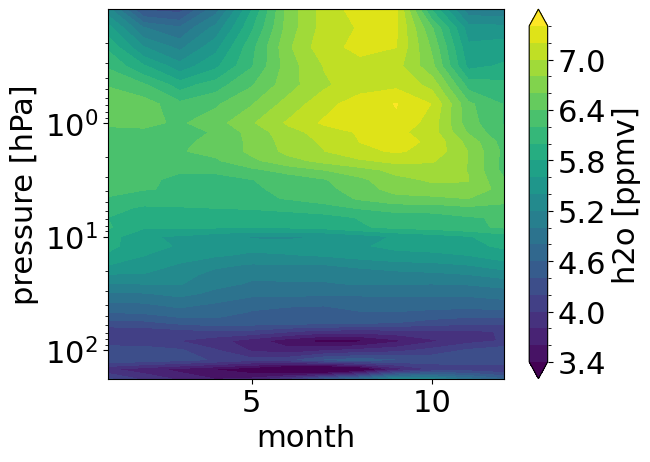

In [202]:
clim_mon['h2o'].sel(
    latitude_bins = slice(60,None),
    #time = slice('2024-08', '2025-03'),
    pressure = slice(200,0.1),  
).weighted(weights).mean('latitude_bins').plot.contourf(x = 'month', yincrease = False, robust = True, levels = 21)
plt.yscale('log')

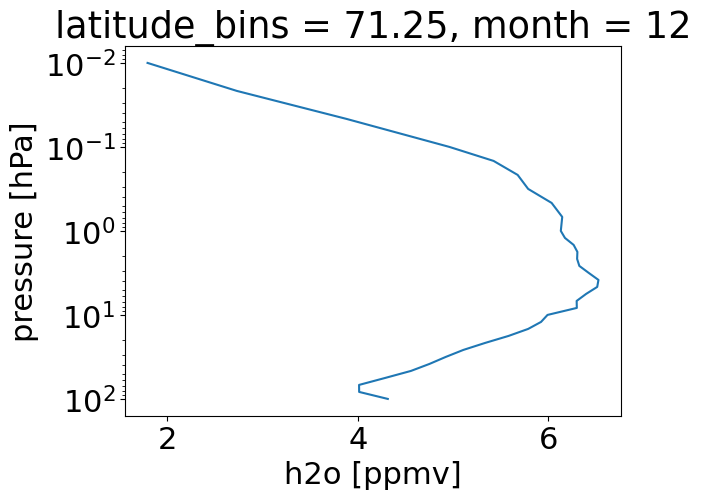

In [210]:
clim_mon['h2o'].sel(
    latitude_bins = 70, 
    month = 12, 
    method='nearest'
).sel(pressure = slice(100,0.01)).plot(yincrease = False, y = 'pressure')
plt.yscale('log')

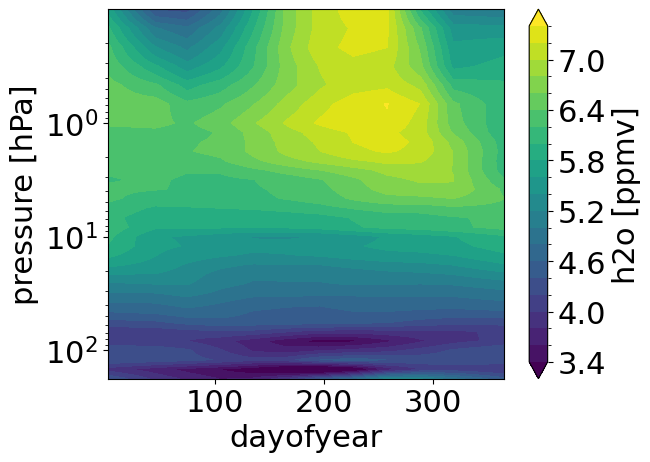

In [94]:
clim_mon_new['h2o'].sel(
    latitude_bins = slice(60,None),
    #time = slice('2024-08', '2025-03'),
    pressure = slice(200,0.1),
    
).weighted(weights).mean('latitude_bins').plot.contourf(x = 'dayofyear', yincrease = False, robust = True, levels = 21)
plt.yscale('log')

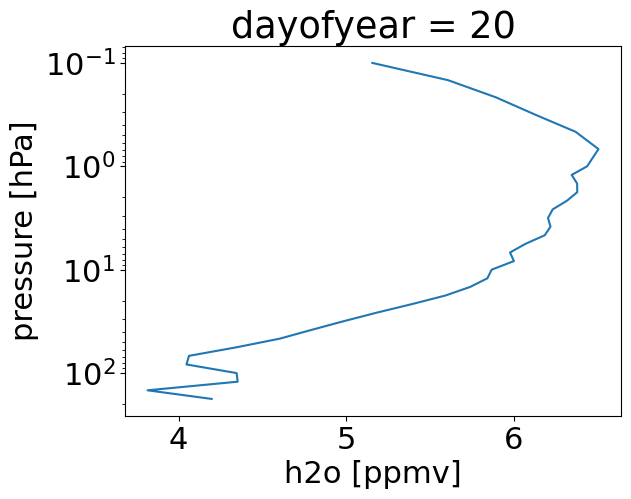

In [97]:
clim_mon_new['h2o'].sel(
    latitude_bins = slice(60,None),
    dayofyear = 20,
    pressure = slice(200,0.1),
    
).weighted(weights).mean('latitude_bins').plot(yincrease = False, y = 'pressure')
plt.yscale('log')

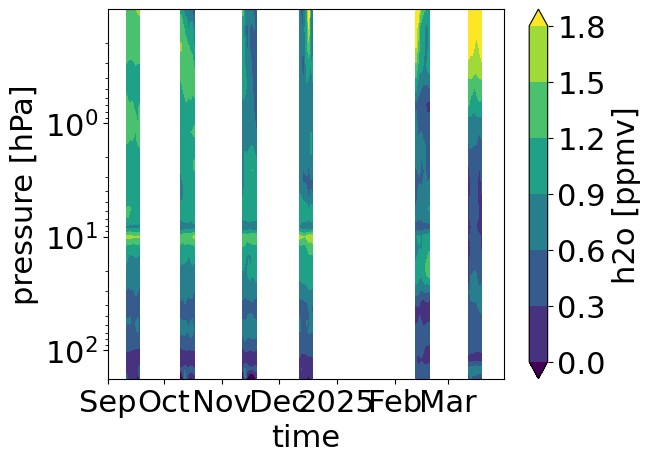

In [130]:
 temp = anom_int['h2o'].sel(
            latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,0.1),    
        ).weighted(weights).mean('latitude_bins')
#temp = temp.resample(time = '1M').mean().interpolate_na(dim = 'time')
temp.plot.contourf(yincrease = False, y = 'pressure', robust=True)
plt.yscale('log')

In [132]:
temp

<xarray.DataArray 'h2o' (time: 212, pressure: 34)> Size: 58kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * pressure   (pressure) float32 136B 177.8 146.8 121.2 ... 0.2154 0.1468 0.1
  * time       (time) datetime64[ns] 2kB 2024-09-01 2024-09-02 ... 2025-03-31
    dayofyear  (time) int64 2kB 245 246 247 248 249 250 ... 85 86 87 88 89 90
Attributes:
    units:    ppmv

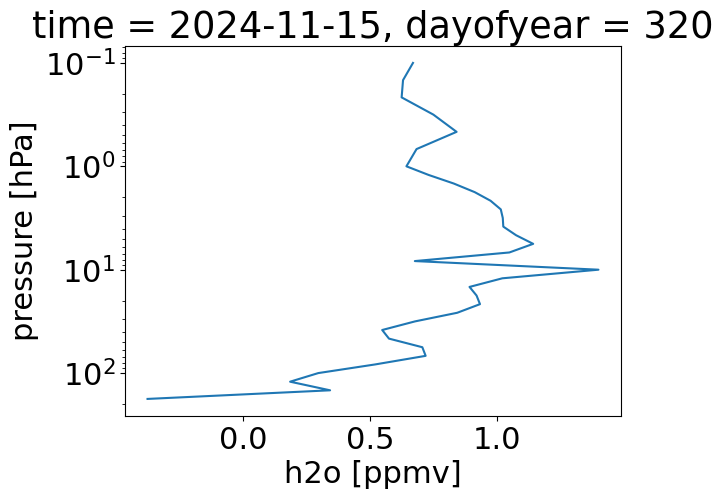

In [137]:
temp.sel(time = '2024-11-15').plot(yincrease = False, y = 'pressure', )
plt.yscale('log')

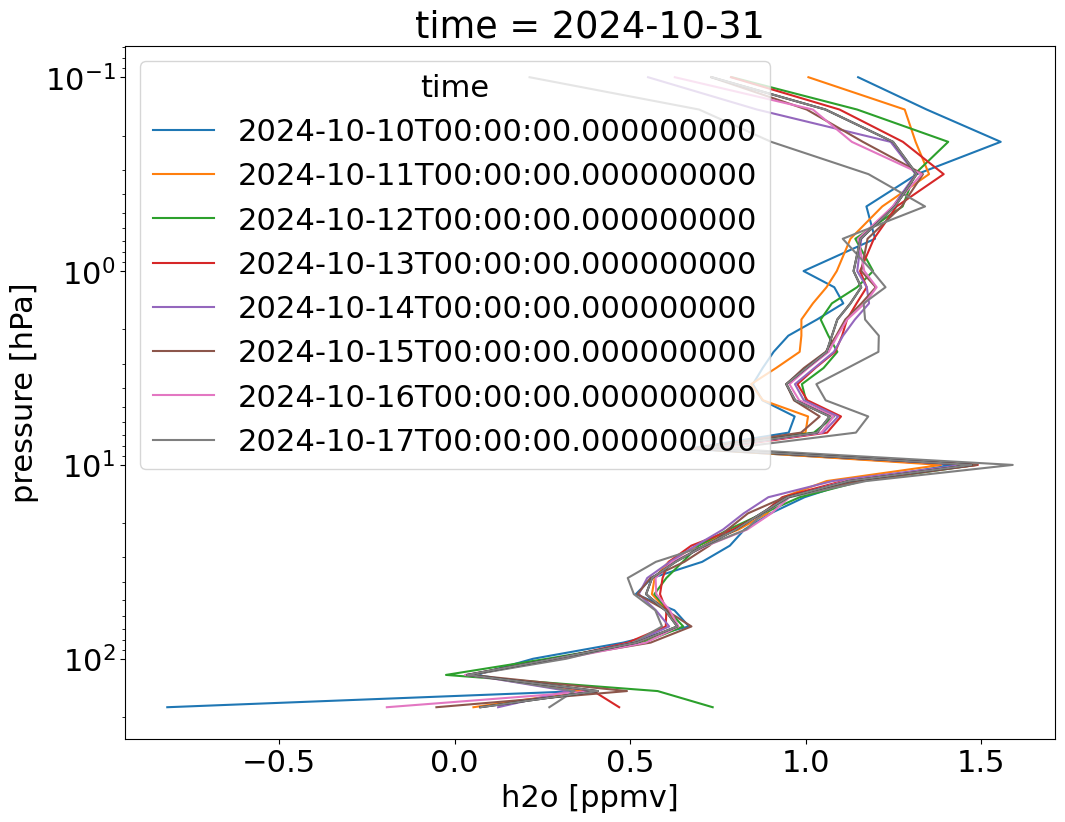

In [151]:
arr = temp.sel(time = slice('2024-10-01','2024-10-30')).dropna('time')
arr.plot(yincrease = False, y = 'pressure', hue = 'time', size  = 9)

arr.resample(time ='1M').mean().plot(yincrease = False, y = 'pressure', c ='k')#.interpolate_na(dim = 'time')
arr.resample(time ='1M').mean().interpolate_na(dim = 'time').plot(yincrease = False, y = 'pressure', c ='gray')
plt.yscale('log')

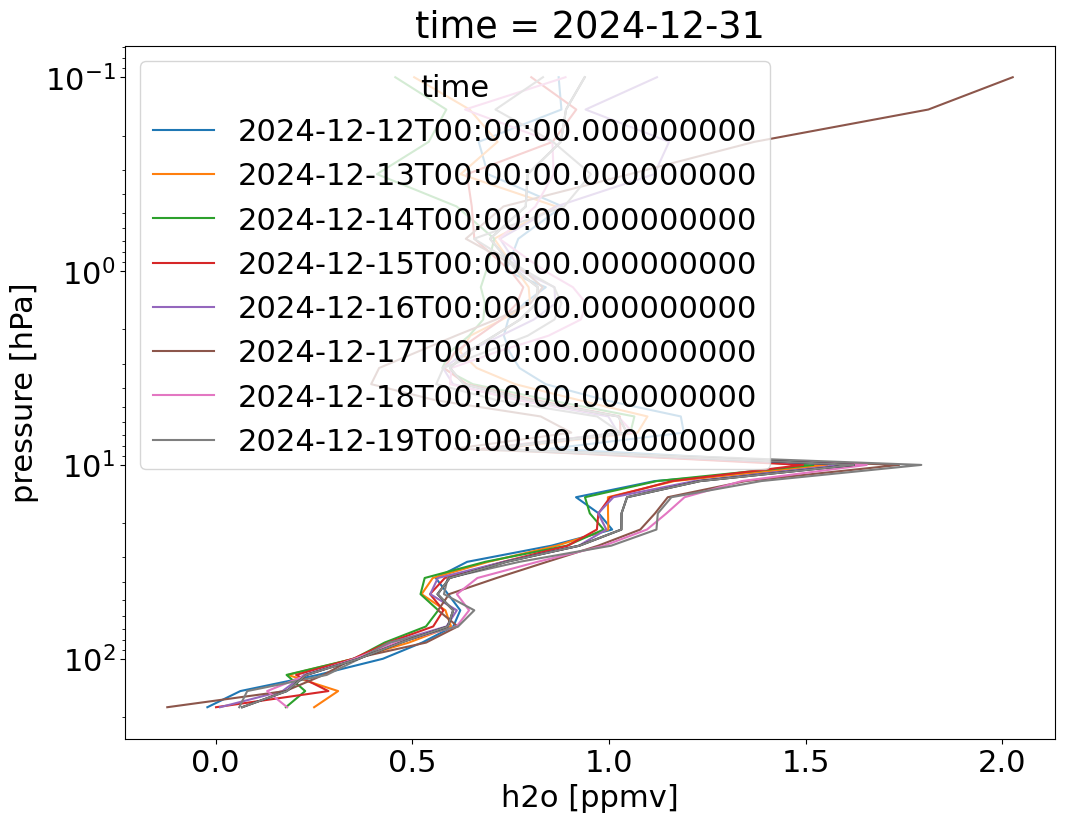

In [150]:
arr = temp.sel(time = slice('2024-12-01','2024-12-31')).dropna('time')
arr.plot(yincrease = False, y = 'pressure', hue = 'time', size  = 9)

arr.resample(time ='1M').mean().plot(yincrease = False, y = 'pressure', c ='k')#.interpolate_na(dim = 'time')
arr.resample(time ='1M').mean().interpolate_na(dim = 'time').plot(yincrease = False, y = 'pressure', c ='gray')
plt.yscale('log')

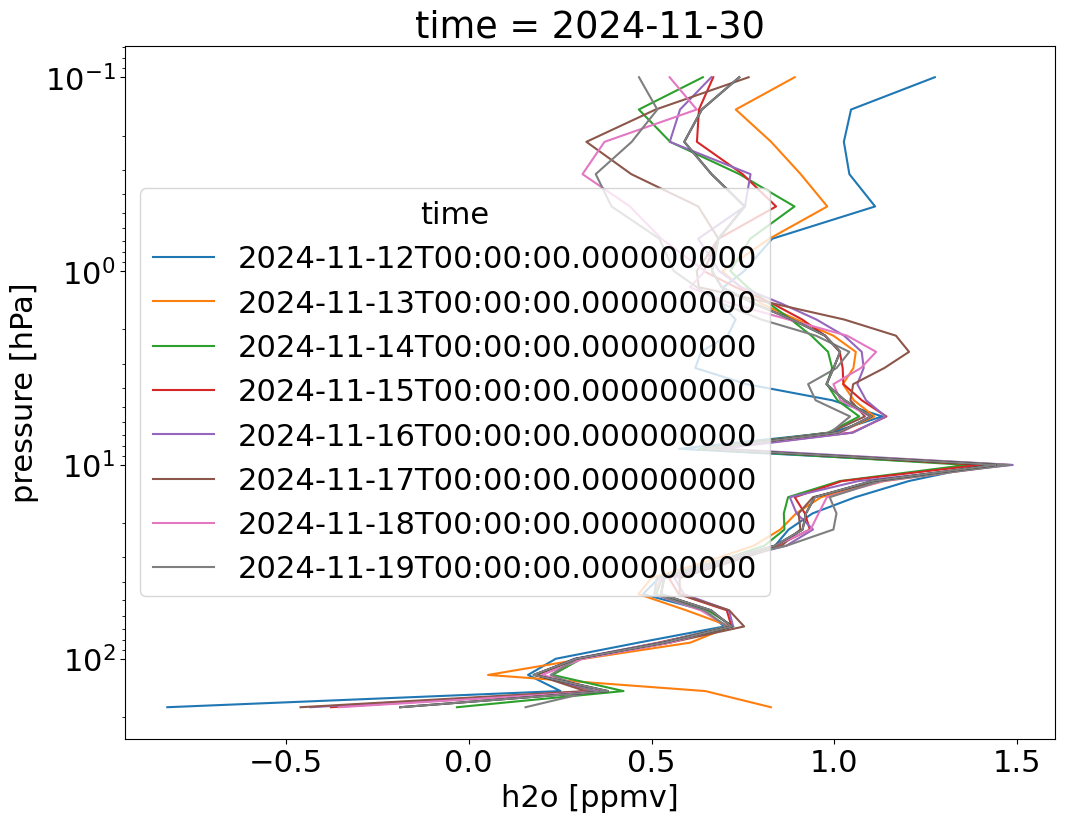

In [149]:
arr = temp.sel(time = slice('2024-11-01','2024-11-30')).dropna('time')
arr.plot(yincrease = False, y = 'pressure', hue = 'time', size  = 9)

arr.resample(time ='1M').mean().plot(yincrease = False, y = 'pressure', c ='k')#.interpolate_na(dim = 'time')
arr.resample(time ='1M').mean().interpolate_na(dim = 'time').plot(yincrease = False, y = 'pressure', c ='gray')
plt.yscale('log')

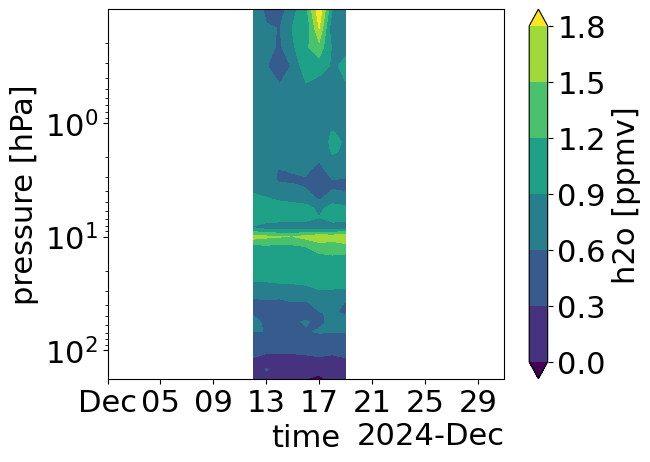

In [173]:
temp.sel(time = slice('2024-12-01','2024-12-31')).plot.contourf(yincrease = False, y = 'pressure', robust=True)
plt.yscale('log')

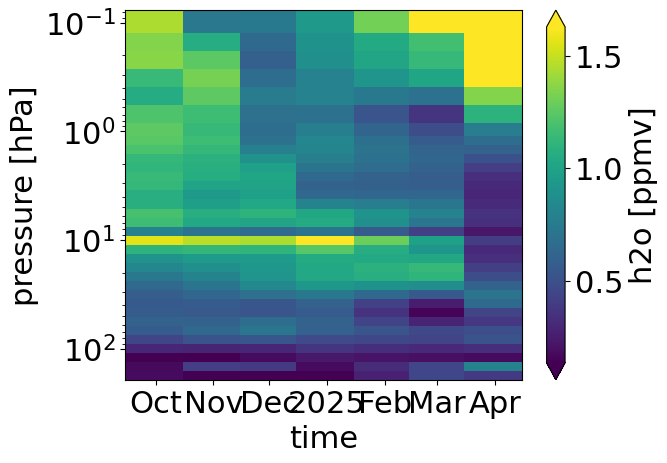

In [155]:
temp.resample(time ='1M').mean().interpolate_na(dim = 'time').plot(yincrease = False, y = 'pressure', robust = True)
plt.yscale('log')

In [170]:
temp.resample(time ='1M', origin='start', offset=pd.Timedelta('15D')).mean().shift(time = 15)

<xarray.DataArray 'h2o' (time: 7, pressure: 34)> Size: 2kB
array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan]])
Coordinates:
  * pressure  (pressure) float32 136B 177.8 146.8 121.2 ... 0.2154 0.1468 0.1
  * time      (time) datetime64[ns] 56B 2024-09-30 2024-10-31 ... 2025-03-31
Attributes:
    units:    ppmv

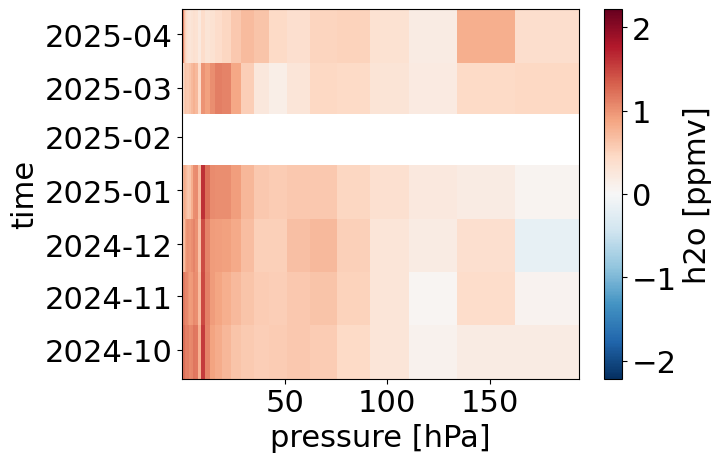

In [165]:
temp.resample(time ='1M', origin='start', offset=pd.Timedelta('15D')).mean().plot()

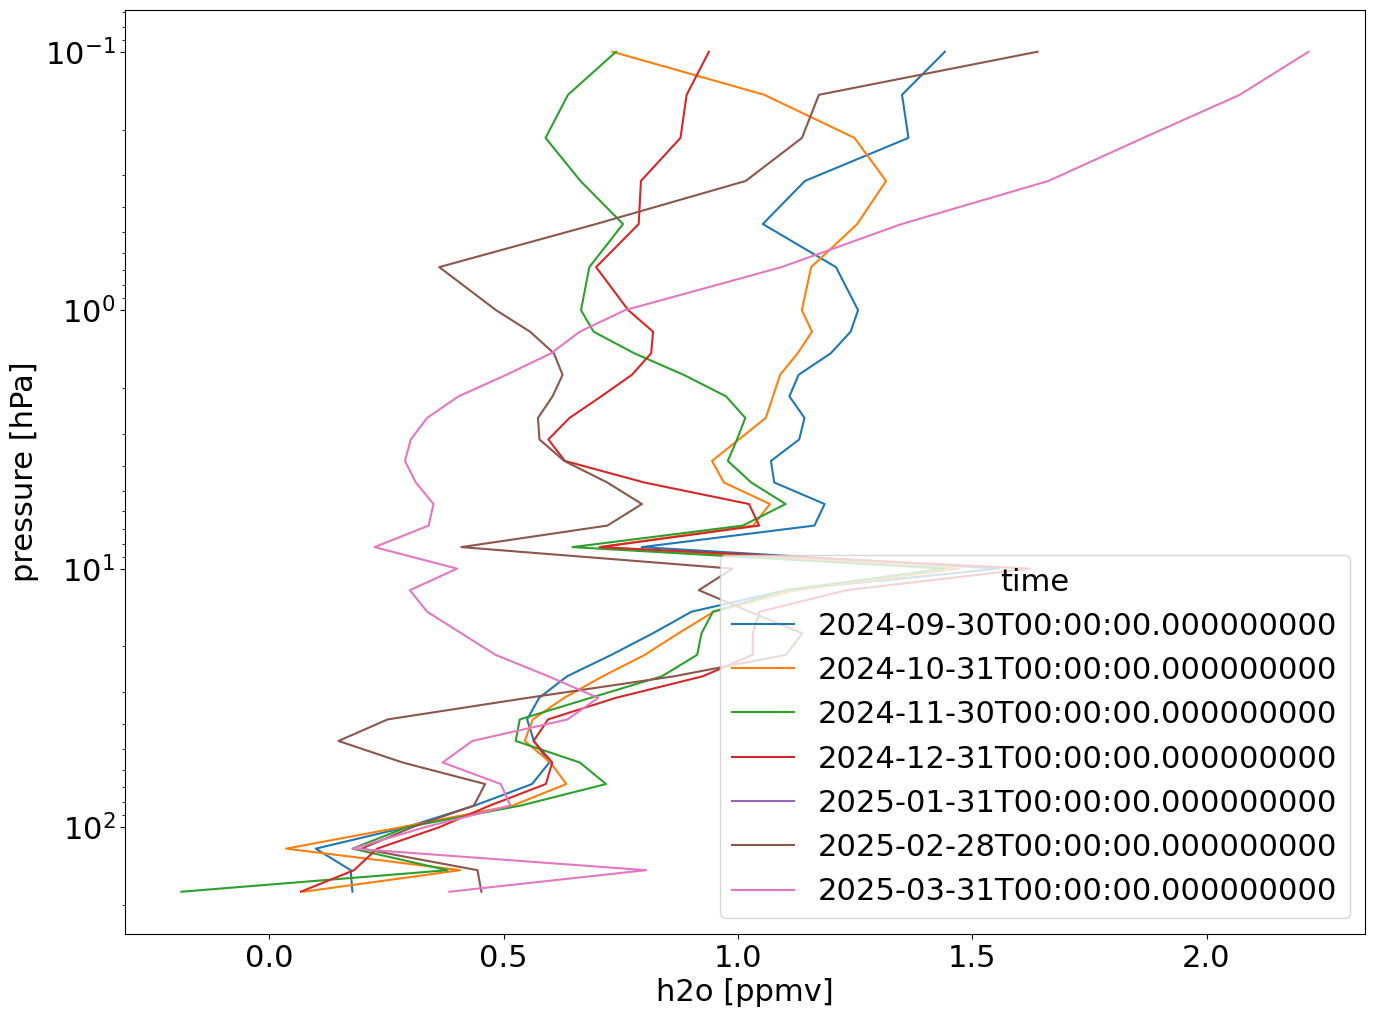

In [166]:
temp.resample(time ='1M', origin='start').mean().plot(yincrease = False, y = 'pressure', hue = 'time', size = 12)
plt.yscale('log')

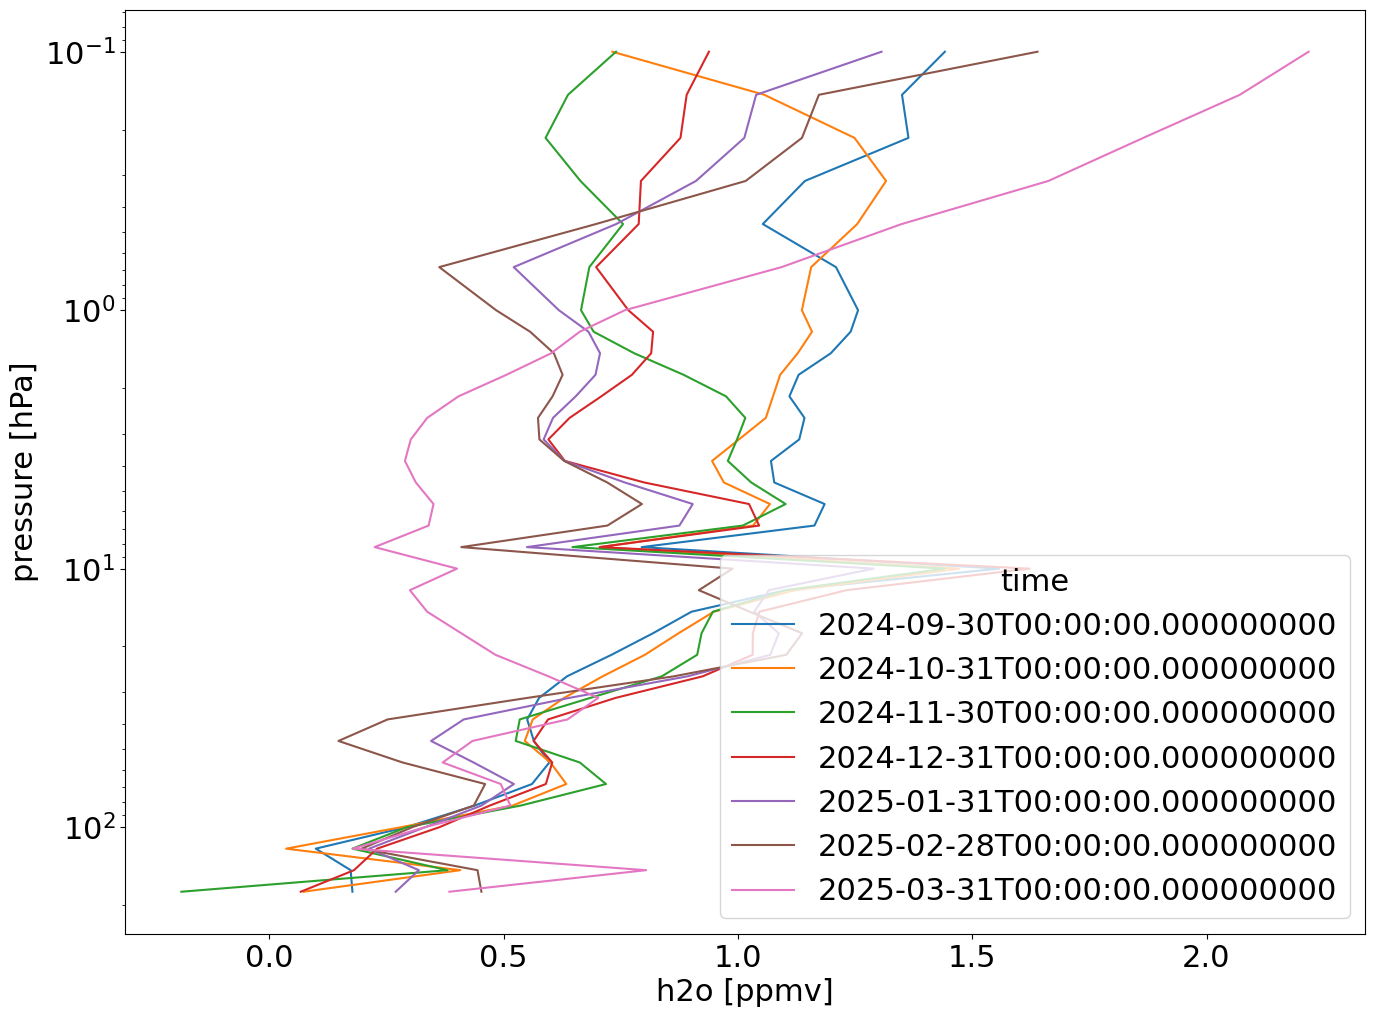

In [162]:
temp.resample(time ='1M', origin='start').mean().interpolate_na(dim = 'time').plot(yincrease = False, y = 'pressure', hue = 'time', size = 12)
plt.yscale('log')

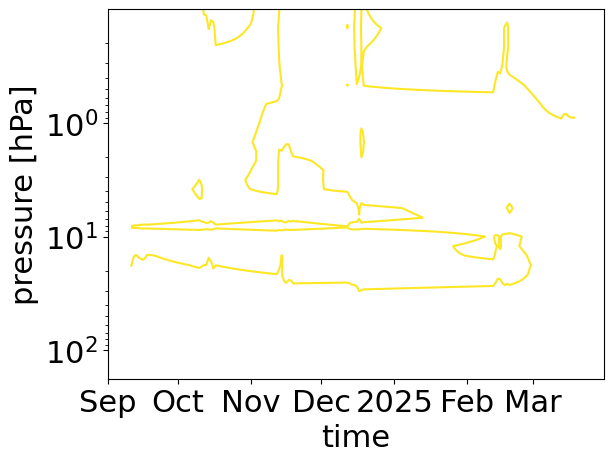

In [127]:
temp.interpolate_na("time").plot.contour(yincrease = False, y = 'pressure', robust=True, levels = 1)
plt.yscale('log')

In [172]:
pd.date_range('2024-10-15', freq='30D', periods=10)

DatetimeIndex(['2024-10-15', '2024-11-14', '2024-12-14', '2025-01-13',
               '2025-02-12', '2025-03-14', '2025-04-13', '2025-05-13',
               '2025-06-12', '2025-07-12'],
              dtype='datetime64[ns]', freq='30D')

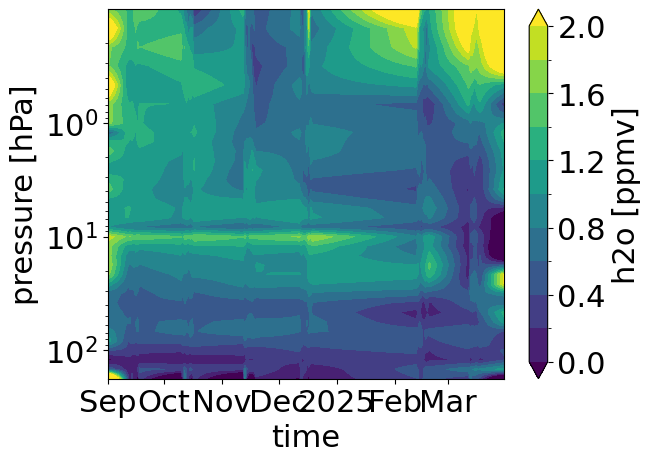

In [161]:
temp.interpolate_na("time", method='linear', fill_value="extrapolate").plot.contourf(yincrease = False, y = 'pressure', robust=True, levels = 11)
plt.yscale('log')

([<matplotlib.axis.YTick at 0x7f54e09a36d0>,
 [])

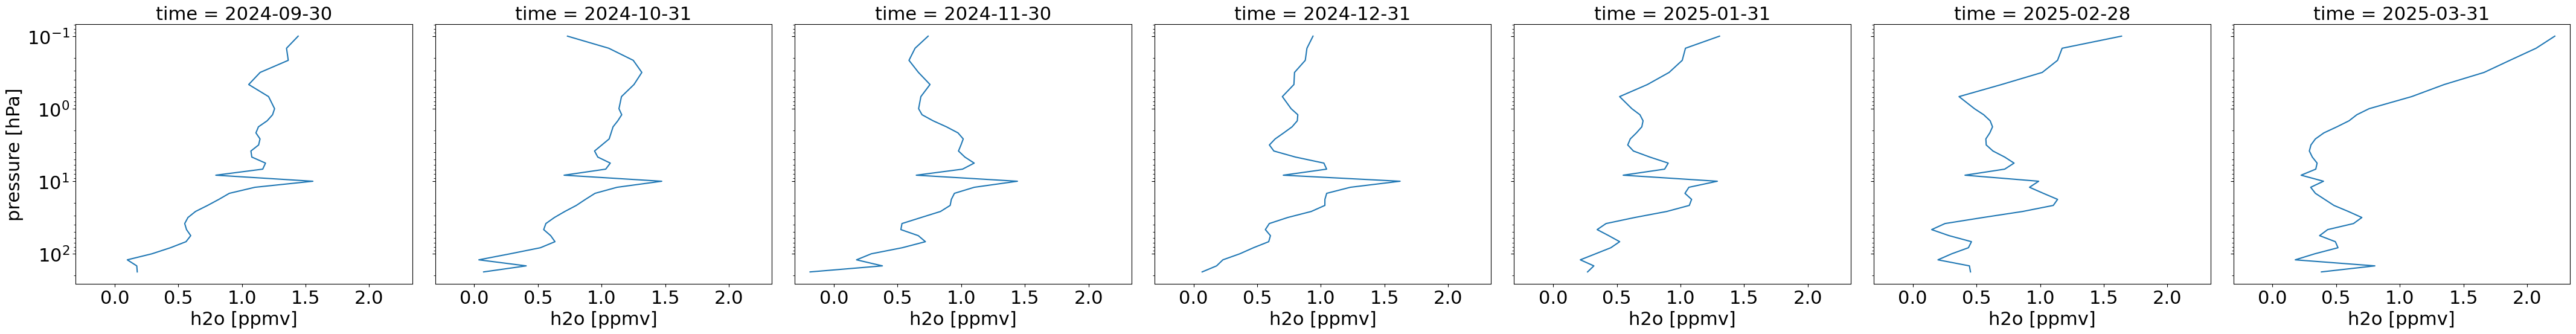

In [121]:
temp.plot(yincrease = False, y = 'pressure', col = 'time',size = 6)
plt.yscale('log')
plt.yticks([100,10,1,0.1])

In [129]:
anom_int

<xarray.Dataset> Size: 706MB
Dimensions:        (pressure: 55, time: 7425, latitude_bins: 72)
Coordinates:
  * pressure       (pressure) float32 220B 1e+03 825.4 681.3 ... 2.154e-05 1e-05
  * time           (time) datetime64[ns] 59kB 2005-01-01 ... 2025-04-30
  * latitude_bins  (latitude_bins) float64 576B -88.75 -86.25 ... 86.25 88.75
    dayofyear      (time) int64 59kB 1 2 3 4 5 6 7 ... 115 116 117 118 119 120
Data variables:
    h2o            (latitude_bins, time, pressure) float64 235MB nan nan ... nan
    O3             (latitude_bins, time, pressure) float64 235MB nan nan ... nan
    temperature    (latitude_bins, time, pressure) float64 235MB nan nan ... nan

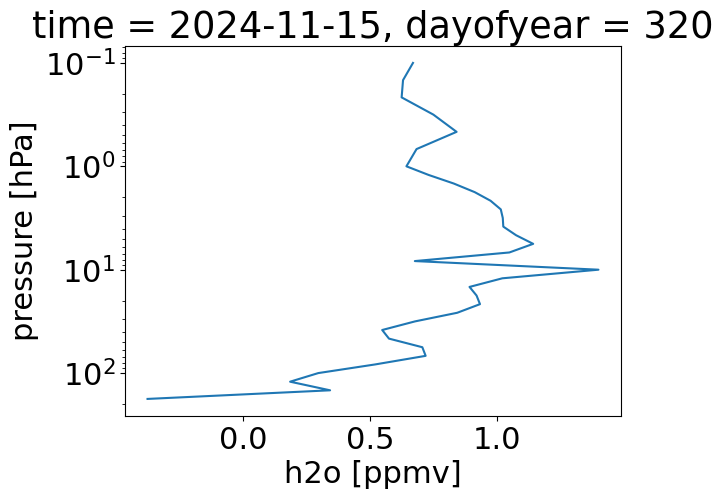

In [102]:
anom_int['h2o'].sel(
    latitude_bins = slice(60,None),
    time = '2024-11-15',
    pressure = slice(200,0.1),
    
).weighted(weights).mean('latitude_bins').plot(yincrease = False, y = 'pressure')
plt.yscale('log')

In [85]:
clim_mon_new['h2o']

<xarray.DataArray 'h2o' (latitude_bins: 72, dayofyear: 366, pressure: 55)> Size: 6MB
dask.array<transpose, shape=(72, 366, 55), dtype=float32, chunksize=(72, 366, 55), chunktype=numpy.ndarray>
Coordinates:
  * pressure       (pressure) float32 220B 1e+03 825.4 681.3 ... 2.154e-05 1e-05
  * latitude_bins  (latitude_bins) float64 576B -88.75 -86.25 ... 86.25 88.75
  * dayofyear      (dayofyear) int64 3kB 1 2 3 4 5 6 ... 361 362 363 364 365 366
Attributes:
    units:    ppmv

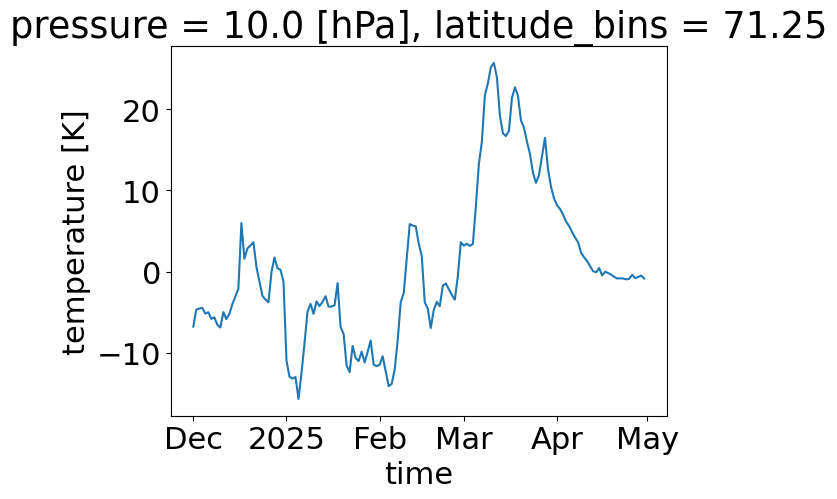

In [81]:
#anom_mon['temperature'].sel(pressure = 10, latitude_bins = 71.25, time = slice('2024-12',None)).plot()
#anom_doy['temperature'].sel(pressure = 10, latitude_bins = 71.25, time = slice('2024-12',None)).plot()
anom_int['temperature'].sel(pressure = 10, latitude_bins = 71.25, time = slice('2024-12',None)).plot()

In [70]:
anom_int['temperature'].sel(pressure = 10, latitude_bins = 71.25, time = slice('2024-12','2024-12-31'))

<xarray.DataArray 'temperature' (time: 31)> Size: 248B
array([-6.76692397, -4.67958906, -4.53929089, -4.46254558, -5.1649293 ,
       -4.98923074, -5.80864937, -5.62905982, -6.54436468, -6.86869664,
       -4.98431889, -5.85297763, -5.20877321, -4.00530366, -3.04942322,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan])
Coordinates:
    pressure       float32 4B 10.0
  * time           (time) datetime64[ns] 248B 2024-12-01 ... 2024-12-31
    latitude_bins  float64 8B 71.25
    dayofyear      (time) int64 248B 336 337 338 339 340 ... 362 363 364 365 366
Attributes:
    units:    K

In [77]:
clim_mon_new['temperature'].sel(pressure = 10, latitude_bins = 71.25).values

array([214.83259583, 214.88922119, 214.94584656, 215.00247192,
       215.05909729, 215.11572266, 215.17234802, 215.22897339,
       215.28559875, 215.34222412, 215.39884949, 215.45547485,
       215.51210022, 215.56872559, 215.62535095, 215.68197632,
       215.73860168, 215.79522705, 215.85185242, 215.90847778,
       215.96510315, 216.02172852, 216.07835388, 216.13497925,
       216.19160461, 216.24822998, 216.30485535, 216.36148071,
       216.41810608, 216.47473145, 216.53135681, 216.58798218,
       216.64460754, 216.70123291, 216.75785828, 216.81448364,
       216.87110901, 216.92773438, 216.98435974, 217.04098511,
       217.09761047, 217.15423584, 217.21086121, 217.26748657,
       217.32411194, 217.35929818, 217.39448442, 217.42967066,
       217.4648569 , 217.50004315, 217.53522939, 217.57041563,
       217.60560187, 217.64078811, 217.67597435, 217.71116059,
       217.74634684, 217.78153308, 217.81671932, 217.85190556,
       217.8870918 , 217.92227804, 217.95746428, 217.99

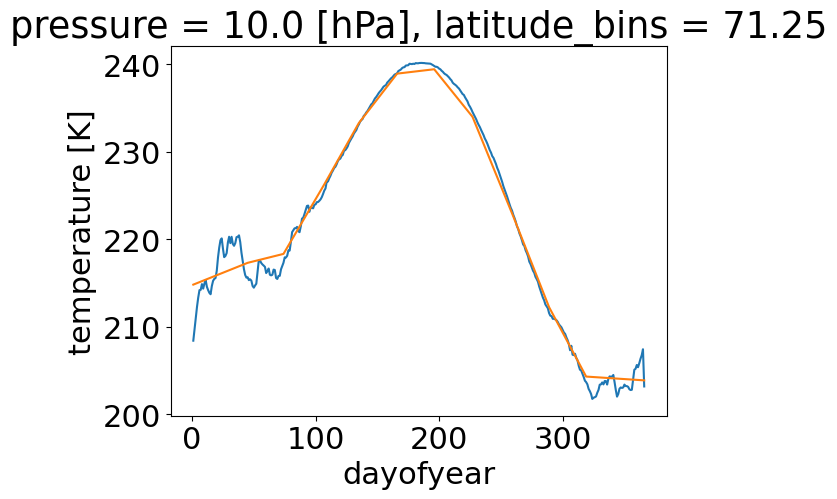

In [78]:
clim_doy['temperature'].sel(pressure = 10, latitude_bins = 71.25).plot()
clim_mon_new['temperature'].sel(pressure = 10, latitude_bins = 71.25).plot()

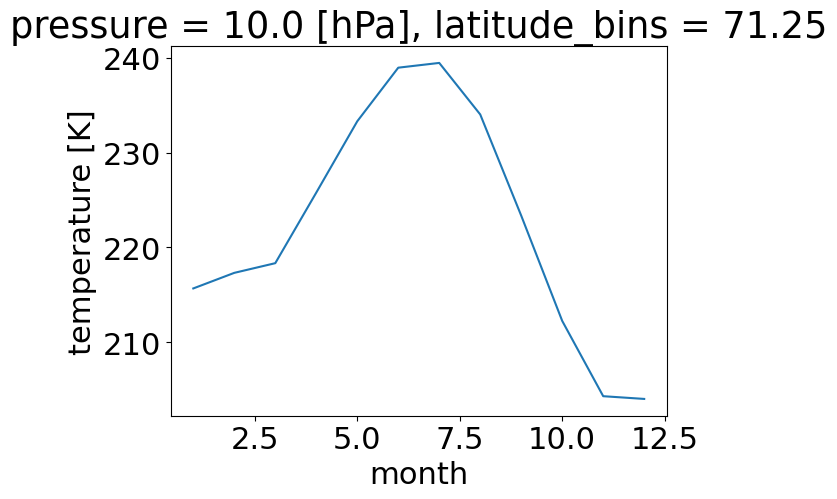

In [79]:
clim_mon['temperature'].sel(pressure = 10, latitude_bins = 71.25).plot()

In [49]:
366-30+15

351

In [47]:
np.arange(15,400,30)

array([ 15,  45,  75, 105, 135, 165, 195, 225, 255, 285, 315, 345, 375])

In [56]:
clim_mon_new = clim_mon.copy()
clim_mon_new = clim_mon_new.rename({'month': 'dayofyear'})
clim_mon_new['dayofyear'] = [16, 45, 74, 105, 135, 166, 196, 227, 258, 289, 319, 350]
clim_mon_new.interp(dayofyear = )

<xarray.Dataset> Size: 571kB
Dimensions:        (latitude_bins: 72, dayofyear: 12, pressure: 55)
Coordinates:
  * pressure       (pressure) float32 220B 1e+03 825.4 681.3 ... 2.154e-05 1e-05
  * latitude_bins  (latitude_bins) float64 576B -88.75 -86.25 ... 86.25 88.75
  * dayofyear      (dayofyear) int64 96B 16 45 74 105 135 ... 258 289 319 350
Data variables:
    h2o            (latitude_bins, dayofyear, pressure) float32 190kB dask.array<chunksize=(72, 12, 55), meta=np.ndarray>
    O3             (latitude_bins, dayofyear, pressure) float32 190kB dask.array<chunksize=(72, 12, 55), meta=np.ndarray>
    temperature    (latitude_bins, dayofyear, pressure) float32 190kB dask.array<chunksize=(72, 12, 55), meta=np.ndarray>

In [60]:
clim_mon_new.interp(dayofyear = np.arange(1,367))

<xarray.Dataset> Size: 17MB
Dimensions:        (latitude_bins: 72, dayofyear: 366, pressure: 55)
Coordinates:
  * pressure       (pressure) float32 220B 1e+03 825.4 681.3 ... 2.154e-05 1e-05
  * latitude_bins  (latitude_bins) float64 576B -88.75 -86.25 ... 86.25 88.75
  * dayofyear      (dayofyear) int64 3kB 1 2 3 4 5 6 ... 361 362 363 364 365 366
Data variables:
    h2o            (latitude_bins, dayofyear, pressure) float32 6MB dask.array<chunksize=(72, 366, 55), meta=np.ndarray>
    O3             (latitude_bins, dayofyear, pressure) float32 6MB dask.array<chunksize=(72, 366, 55), meta=np.ndarray>
    temperature    (latitude_bins, dayofyear, pressure) float32 6MB dask.array<chunksize=(72, 366, 55), meta=np.ndarray>

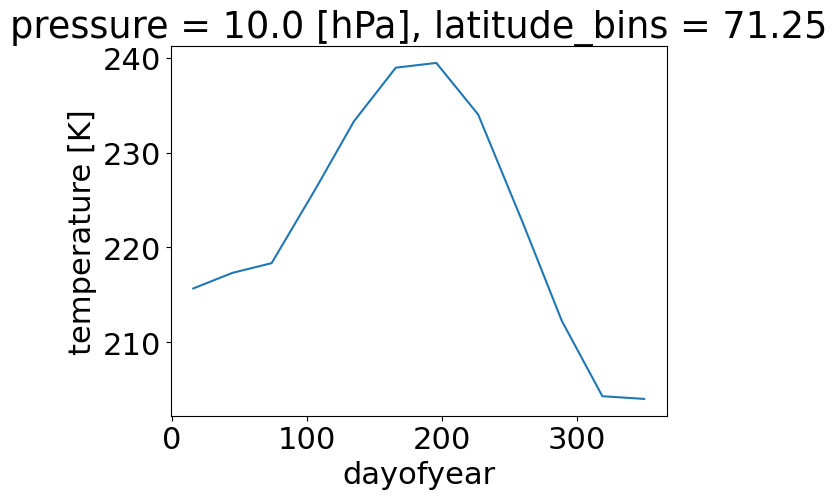

In [59]:
clim_mon_new.interp(dayofyear = np.arange(1,367))['temperature'].sel(pressure = 10, latitude_bins = 71.25).plot()

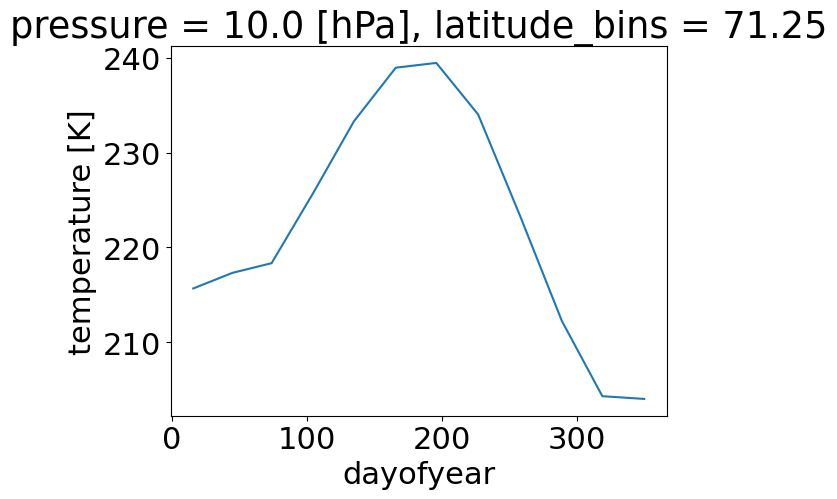

In [58]:
clim_mon_new['temperature'].sel(pressure = 10, latitude_bins = 71.25).plot()

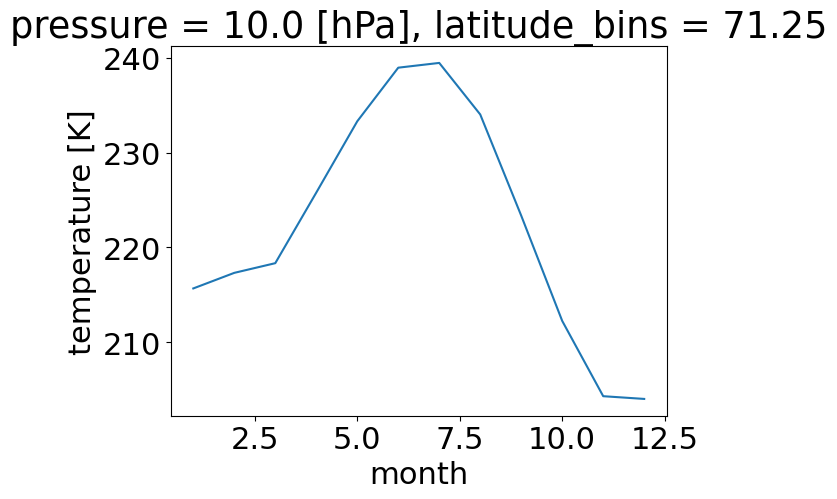

In [42]:
clim_mon['temperature'].sel(pressure = 10, latitude_bins = 71.25).plot()

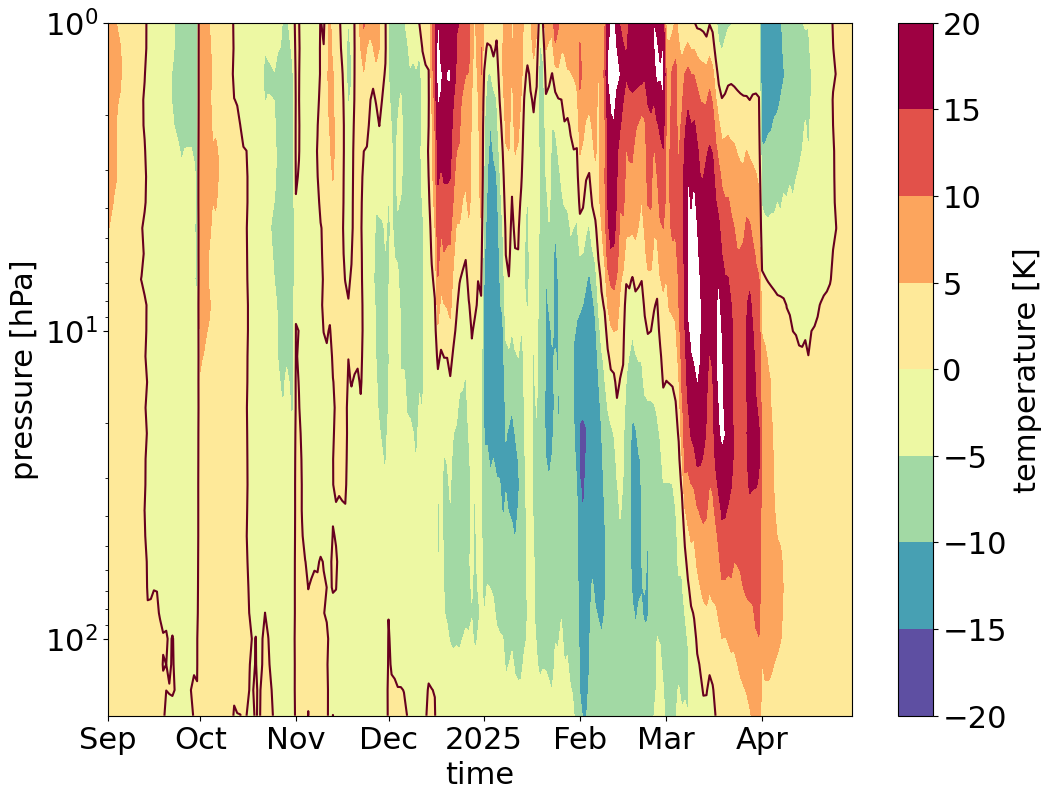

In [31]:
sel_var = 'temperature'
cmap = cm = Colormap('colorbrewer:Spectral_r').to_matplotlib()  # case insensitive

weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
temp = anom_mon[sel_var].sel(
    latitude_bins = slice(60,None),
    time = slice('2024-09', '2025-04'),
    pressure = slice(200,1),
    
).weighted(weights).mean('latitude_bins')
levels = np.arange(-20,25,5)
p = temp.plot.contourf(x = 'time', levels = levels, cmap = cmap, yincrease = False, extend = 'neither', size = 9)
ax = p.axes
temp.plot.contour(x = 'time', yincrease = False, levels = [0], ax = ax, add_colorbar=False,)
ax.set_yscale('log')

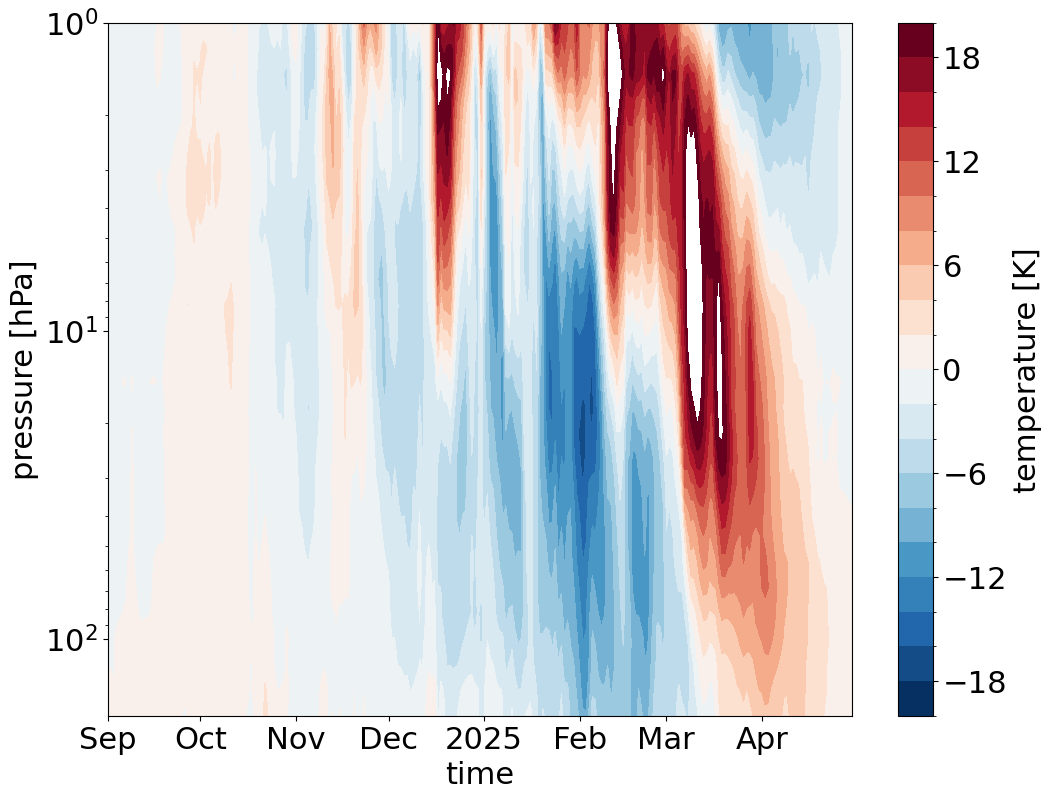

In [35]:
sel_var = 'temperature'
cmap = Colormap('colorbrewer:Spectral_r').to_matplotlib()  # case insensitive

weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
temp = anom_doy[sel_var].sel(
    latitude_bins = slice(60,None),
    time = slice('2024-09', '2025-04'),
    pressure = slice(200,1),
    
).weighted(weights).mean('latitude_bins')
levels = np.arange(-20,25,5)
p = temp.plot.contourf(x = 'time', levels = 21, robust = True, yincrease = False, extend = 'neither', size = 9)
ax = p.axes
#temp.plot.contour(x = 'time', yincrease = False, levels = [0], ax = ax, add_colorbar=False,)
ax.set_yscale('log')

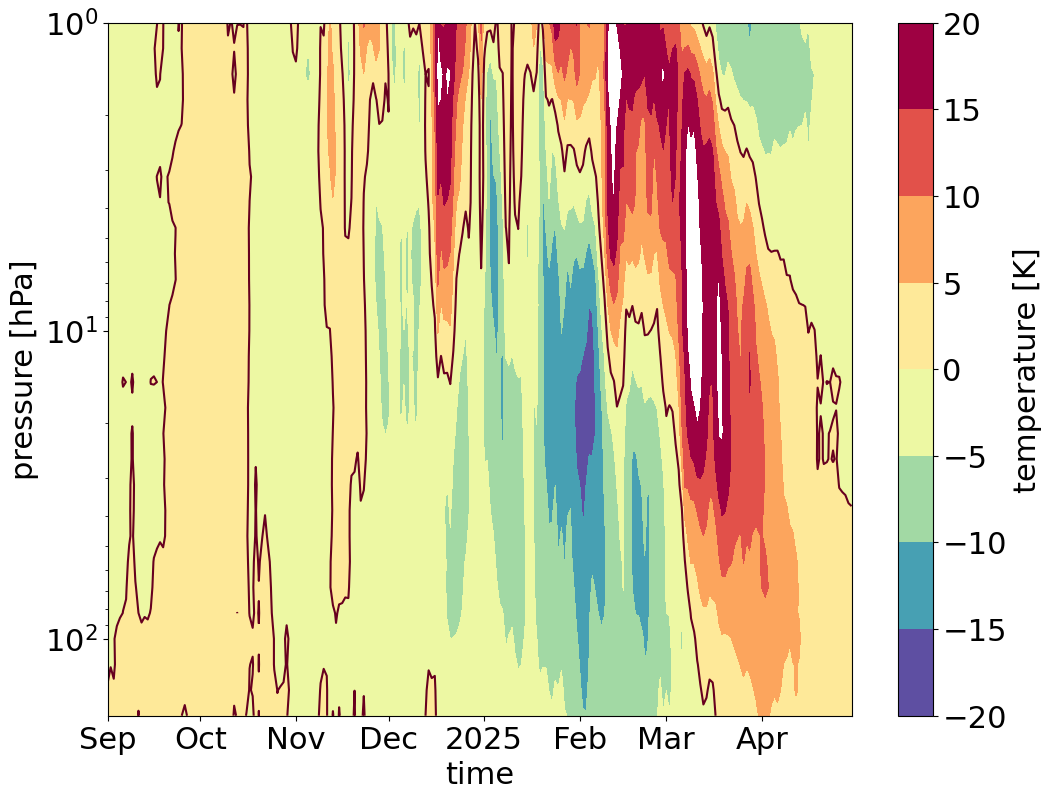

In [30]:
sel_var = 'temperature'
cmap = Colormap('colorbrewer:Spectral_r').to_matplotlib()  # case insensitive

weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
temp = anom_doy[sel_var].sel(
    latitude_bins = slice(60,None),
    time = slice('2024-09', '2025-04'),
    pressure = slice(200,1),
    
).weighted(weights).mean('latitude_bins')
levels = np.arange(-20,25,5)
p = temp.plot.contourf(x = 'time', levels = levels, cmap = cmap, yincrease = False, extend = 'neither', size = 9)
ax = p.axes
temp.plot.contour(x = 'time', yincrease = False, levels = [0], ax = ax, add_colorbar=False,)
ax.set_yscale('log')

In [ ]:
sel_var = 'temperature'
cmap = cm = Colormap('colorbrewer:Spectral_r').to_matplotlib()  # case insensitive

weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
temp = anom_doy[sel_var].sel(
    latitude_bins = slice(60,None),
    time = slice('2024-11', '2024-12'),
    pressure = slice(200,1),
    
).weighted(weights).mean('latitude_bins')
levels = np.arange(-20,25,5)
p = temp.plot.contourf(x = 'time', levels = levels, cmap = cmap, yincrease = False, extend = 'neither', size = 9)
ax = p.axes
temp.plot.contour(x = 'time', yincrease = False, levels = [0], ax = ax, add_colorbar=False,)
ax.set_yscale('log')

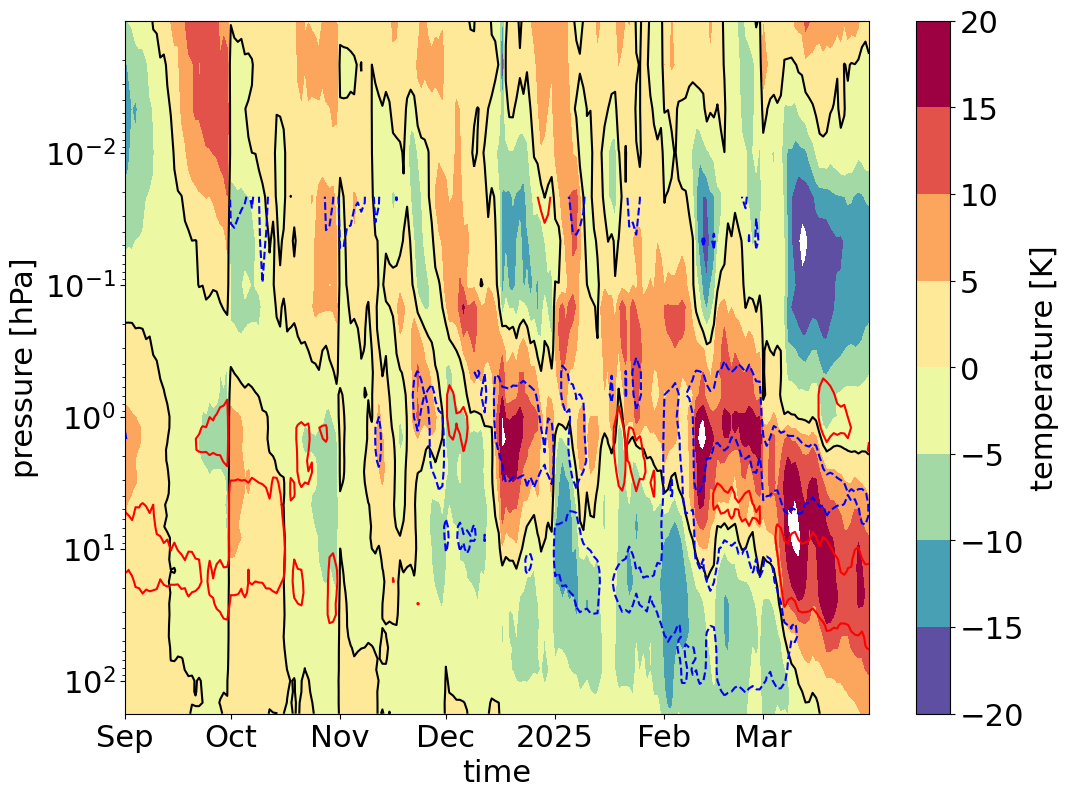

In [17]:
sel_var = 'temperature'
cmap = cm = Colormap('colorbrewer:Spectral_r').to_matplotlib()  # case insensitive

weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
temp = anom[sel_var].sel(
    latitude_bins = slice(60,None),
    time = slice('2024-09', '2025-03'),
    pressure = slice(200,0.001),
    
).weighted(weights).mean('latitude_bins')
levels = np.arange(-20,25,5)
p = temp.plot.contourf(x = 'time', levels = levels, cmap = cmap, yincrease = False, extend = 'neither', size = 9)
ax = p.axes
temp.plot.contour(x = 'time', yincrease = False, levels = [0], colors = ('k'), ax = ax, add_colorbar=False,)

temp = anom['O3'].sel(
    latitude_bins = slice(60,None),
    time = slice('2024-09', '2025-03'),
    pressure = slice(200,0.001),
    
).weighted(weights).mean('latitude_bins')
o3_thres = 0.3
temp.plot.contour(x = 'time', yincrease = False, colors = ('r'), levels = [o3_thres], ax = ax, add_colorbar=False,)
temp.plot.contour(x = 'time', yincrease = False, colors = ('b'), levels = [-o3_thres], ax = ax, add_colorbar=False,)

ax.set_yscale('log')

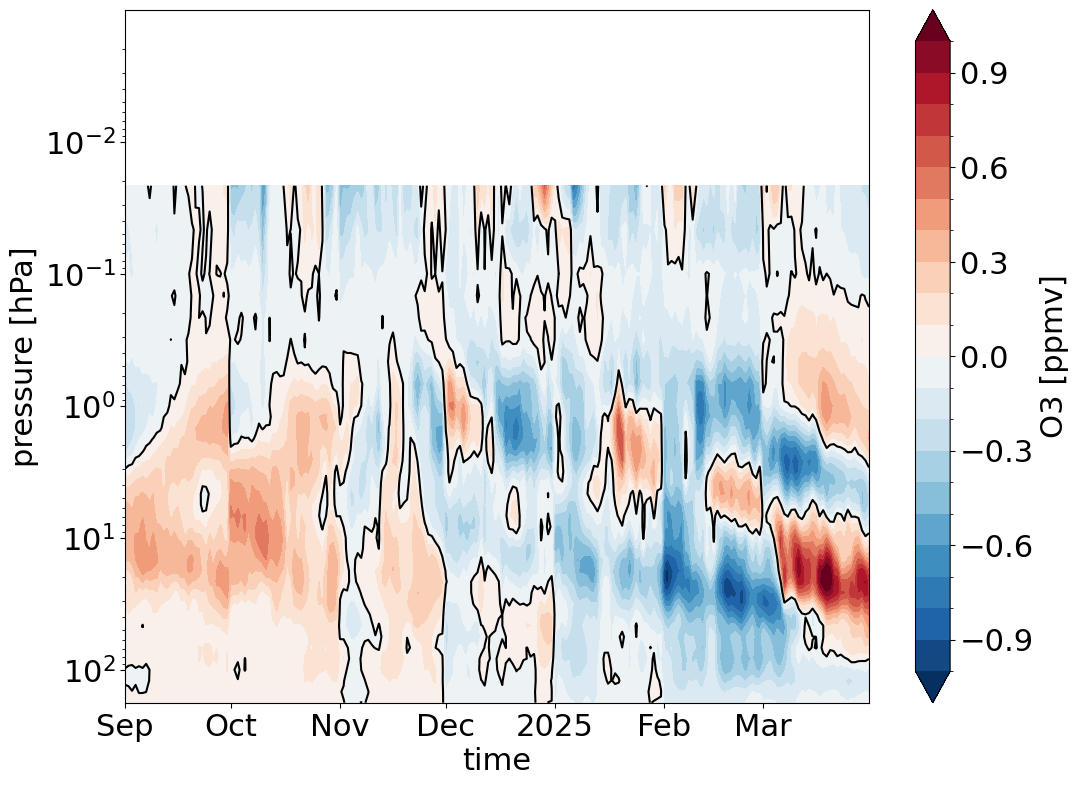

In [11]:
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
temp = anom['O3'].sel(
    latitude_bins = slice(60,None),
    time = slice('2024-09', '2025-03'),
    pressure = slice(200,0.001),
    
).weighted(weights).mean('latitude_bins')
levels = np.arange(-20,25,5)
p = temp.plot.contourf(x = 'time', robust = True, levels = np.linspace(-1,1,21), yincrease = False, size = 9)
ax = p.axes
temp.plot.contour(x = 'time', yincrease = False, colors = ('k'), levels = [0], ax = ax, add_colorbar=False,)
ax.set_yscale('log')

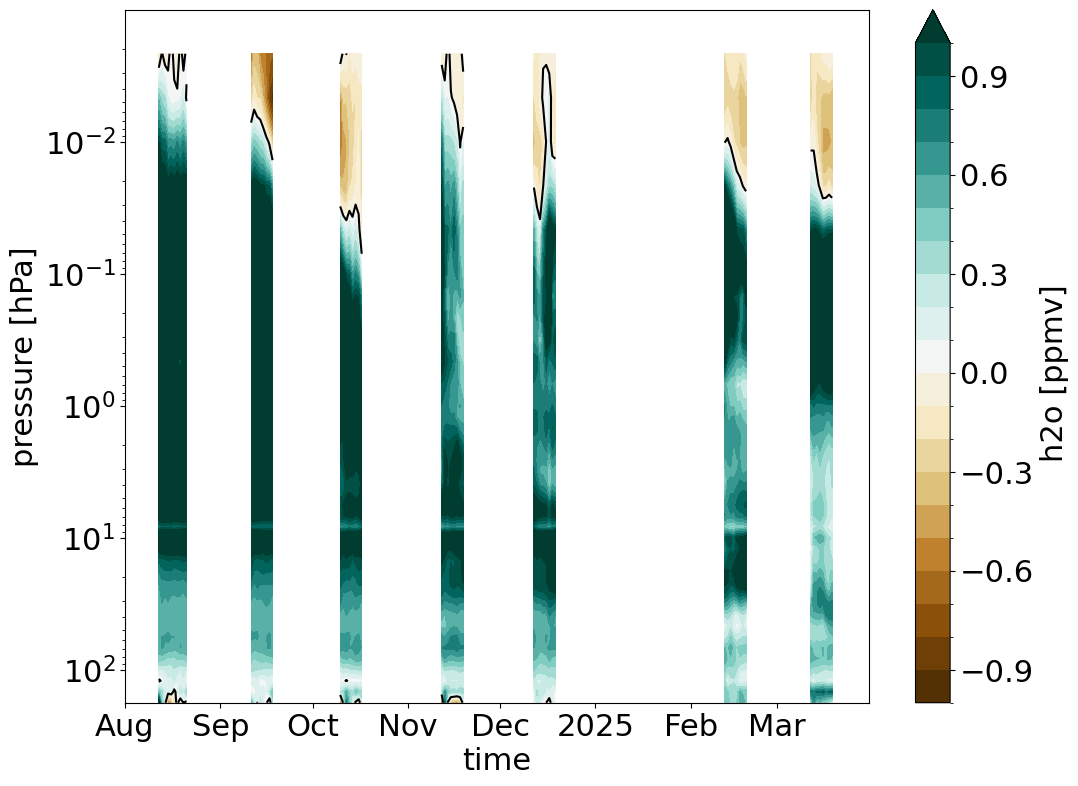

In [92]:
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
temp = anom['h2o'].sel(
    latitude_bins = slice(60,None),
    time = slice('2024-08', '2025-03'),
    pressure = slice(200,0.001),
    
).weighted(weights).mean('latitude_bins')
levels = np.arange(-20,25,5)
p = temp.plot.contourf(x = 'time', robust = True, cmap = 'BrBG', levels = np.linspace(-1,1,21), yincrease = False, size = 9)
ax = p.axes
temp.plot.contour(x = 'time', yincrease = False, colors = ('k'), levels = [0], ax = ax, add_colorbar=False,)
ax.set_yscale('log')

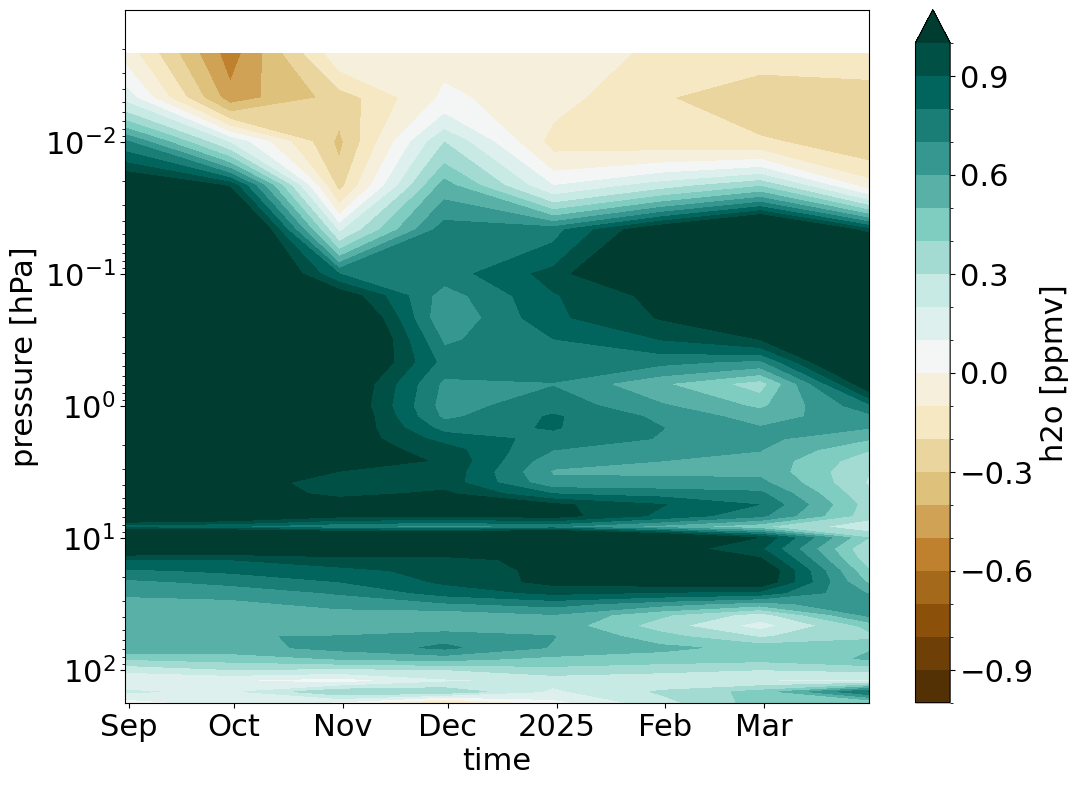

In [97]:
p = temp.resample(time = '1M').mean().interpolate_na(dim = 'time').plot.contourf(x = 'time', robust = True, cmap = 'BrBG', levels = np.linspace(-1,1,21), yincrease = False, size = 9)
ax = p.axes
ax.set_yscale('log')

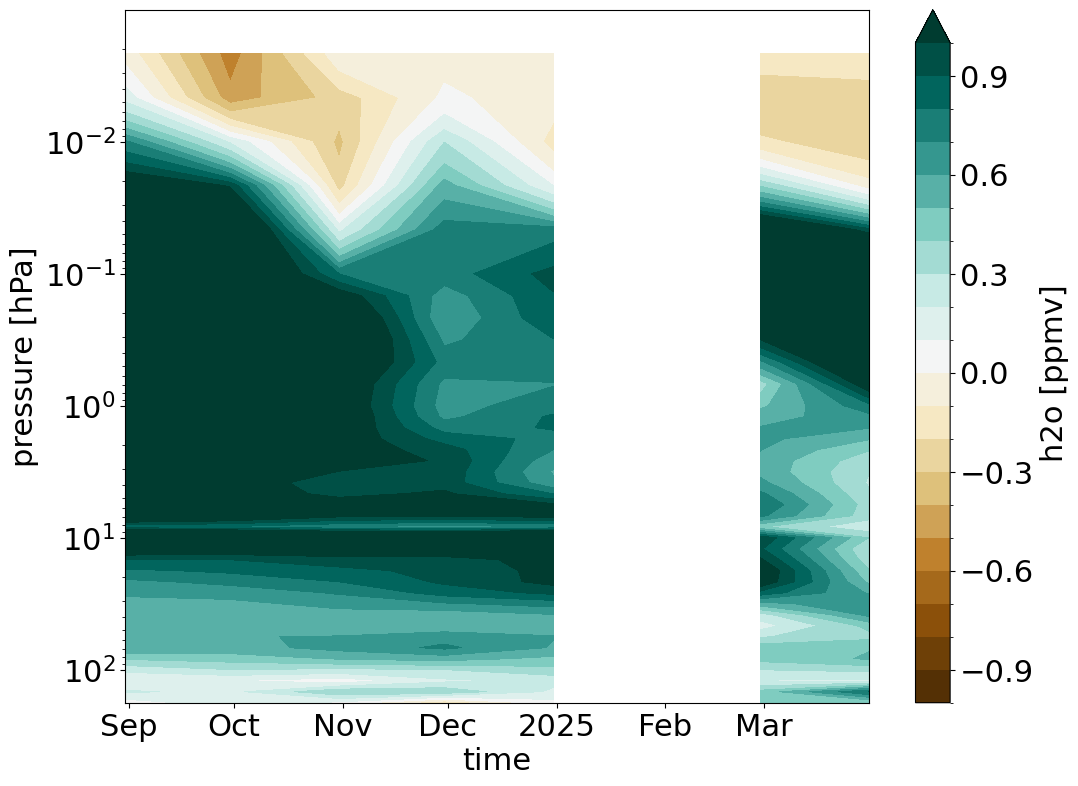

In [93]:
p = temp.resample(time = '1M').mean().plot.contourf(x = 'time', robust = True, cmap = 'BrBG', levels = np.linspace(-1,1,21), yincrease = False, size = 9)
ax = p.axes
ax.set_yscale('log')

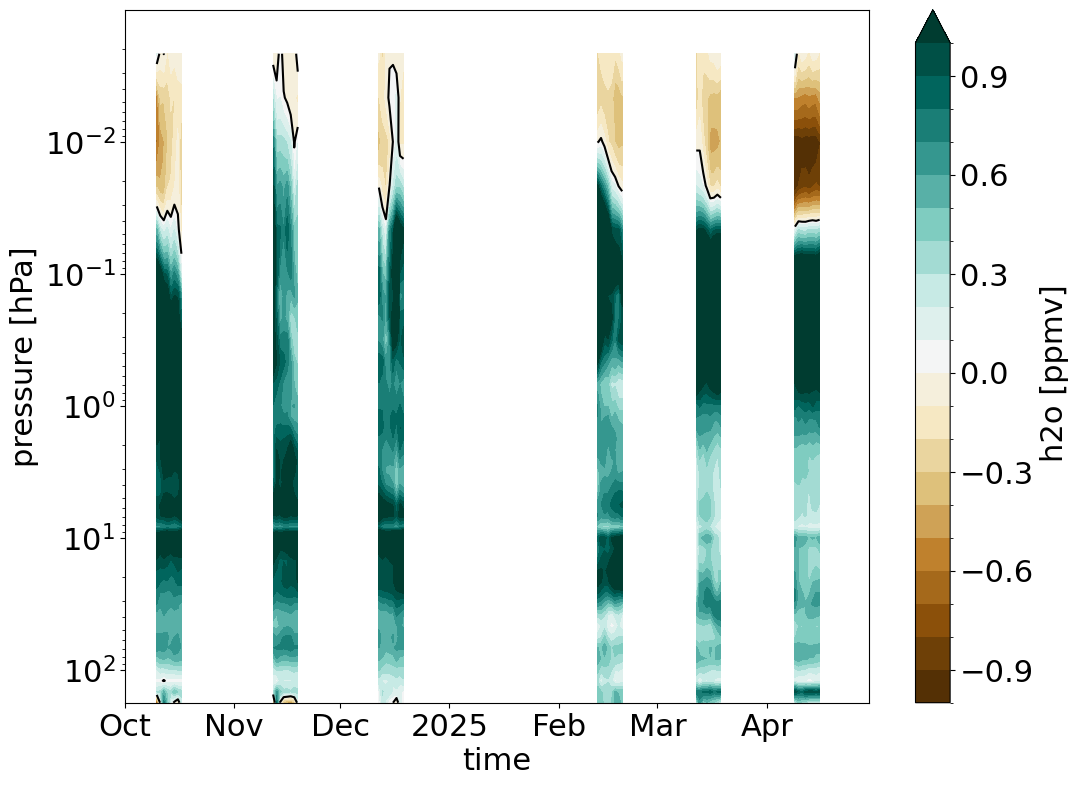

In [99]:
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
temp = anom['h2o'].sel(
    latitude_bins = slice(60,None),
    time = slice('2024-10', '2025-04'),
    pressure = slice(200,0.001),
    
).weighted(weights).mean('latitude_bins')
levels = np.arange(-20,25,5)
p = temp.plot.contourf(x = 'time', robust = True, cmap = 'BrBG', levels = np.linspace(-1,1,21), yincrease = False, size = 9)
ax = p.axes
temp.plot.contour(x = 'time', yincrease = False, colors = ('k'), levels = [0], ax = ax, add_colorbar=False,)
ax.set_yscale('log')

In [102]:
(1.6-1.067)/4

0.13325000000000004

In [103]:
1.6+3*0.13325000000000004

1.9997500000000001

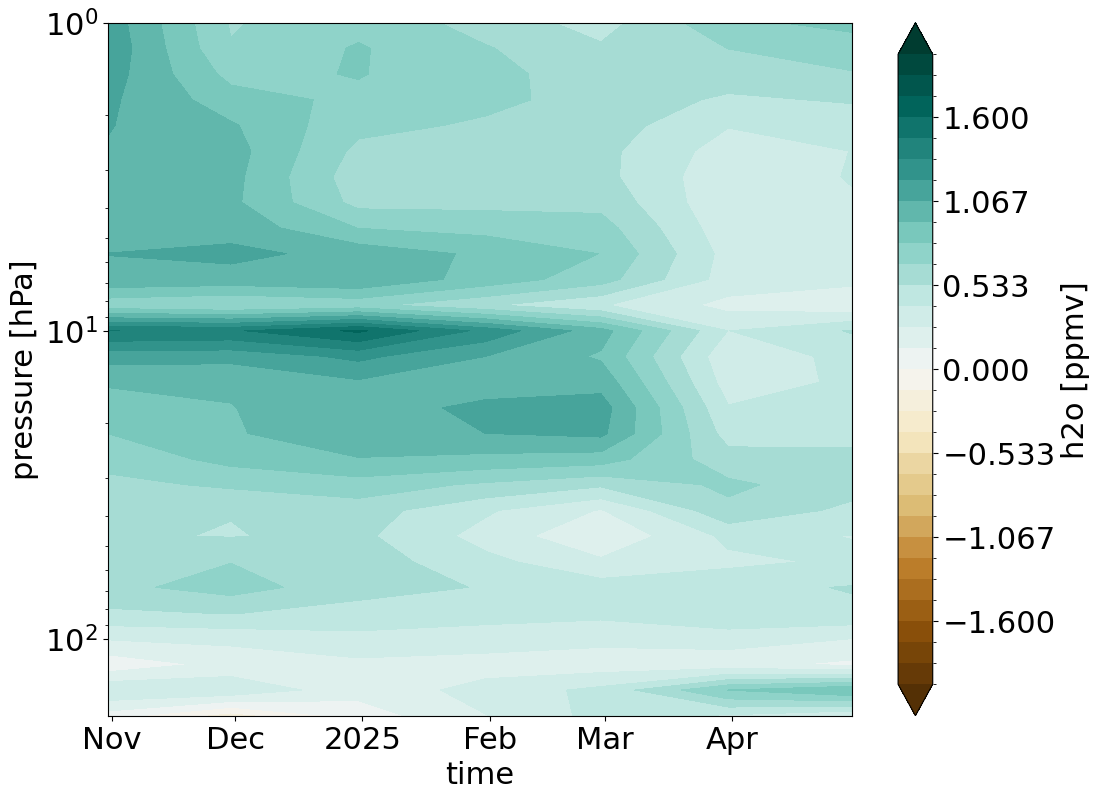

In [105]:
temp_sel = temp.resample(time = '1M').mean().interpolate_na(dim = 'time').sel(pressure = slice(None,1))
p = temp_sel.plot.contourf(
    x = 'time', robust = True, 
    cmap = 'BrBG', levels = np.linspace(-2,2,31), 
    yincrease = False, size = 9,
    extend = 'both'
)
ax = p.axes
ax.set_yscale('log')

In [ ]:
temp_sel = temp.resample(time = '1M').mean().interpolate_na(dim = 'time').sel(pressure = slice(None,1))
p = temp_sel.plot.contourf(x = 'time', robust = True, cmap = 'BrBG', levels = np.linspace(-2,2,21), yincrease = False, size = 9)
ax = p.axes
ax.set_yscale('log')

In [25]:
weights = np.cos(np.deg2rad(anom_h2o.latitude_bins))
weights.name = "weights"
temp = anom_h2o['H2O_mass'].sel(
    latitude_bins = slice(60,None),
    time = slice('2024-09', '2025-03'),
    pressure = slice(200,0.001),
    
).weighted(weights).mean('latitude_bins')
levels = np.arange(-20,25,5)
p = temp.plot.contourf(x = 'time', robust = True, levels = np.linspace(-1,1,21), yincrease = False, size = 9)
ax = p.axes
temp.plot.contour(x = 'time', yincrease = False, colors = ('k'), levels = [0], ax = ax, add_colorbar=False,)
ax.set_yscale('log')

AttributeError: 'Dataset' object has no attribute 'latitude_bins'

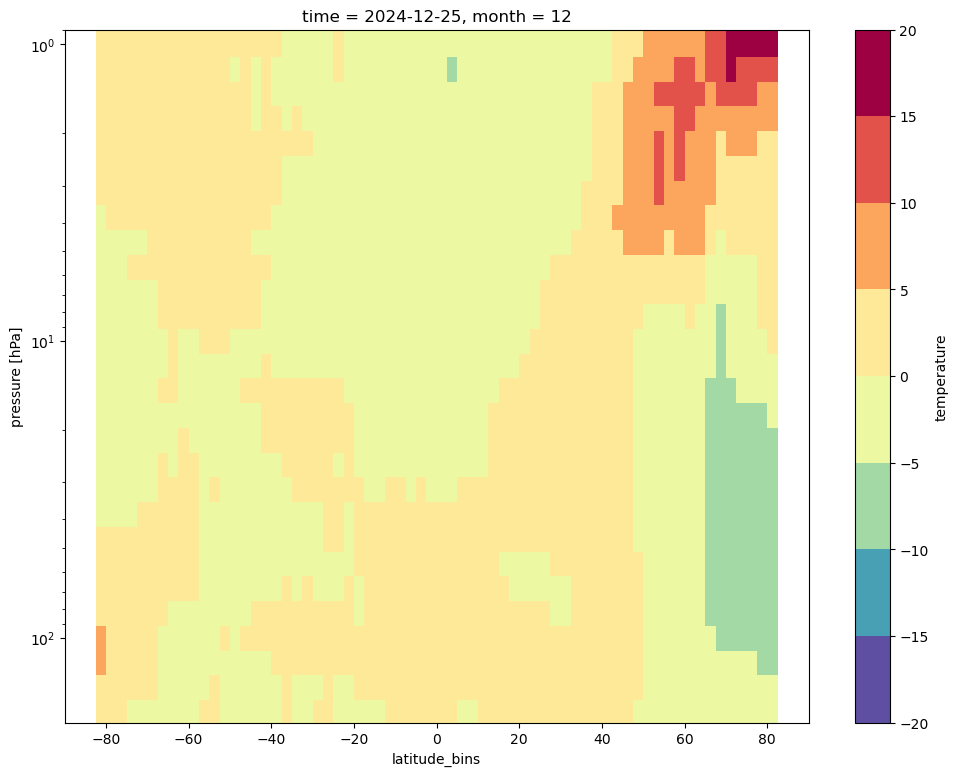

In [48]:
p = anom.sel(
    #latitude_bins = slice(60,None),
    time = '2024-12-25',
    pressure = slice(200,1),
    
).plot(x = 'latitude_bins', yincrease = False,  levels = levels, cmap = cmap, extend = 'neither', size = 9)
ax = p.axes
ax.set_yscale('log')

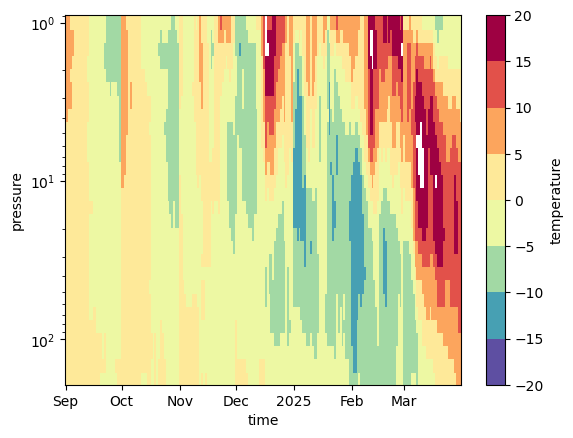

In [21]:
cmap = Colormap('colorbrewer:RdYlBu_r')
temp.sel(pressure = slice(200,1)).plot(x = 'time', levels = levels, cmap = 'Spectral_r', yincrease = False, extend = 'neither')
plt.yscale('log')

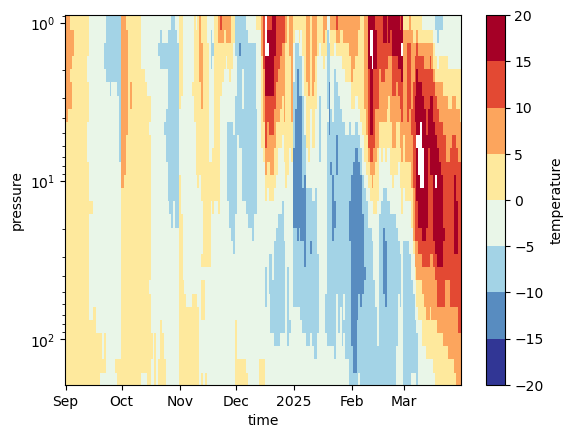

In [23]:
cmap = Colormap('colorbrewer:RdYlBu_r').to_matplotlib
cmap = cm = Colormap('colorbrewer:Spectral').to_matplotlib  # case insensitive
temp.sel(pressure = slice(200,1)).plot(x = 'time', levels = levels, cmap = cmap, yincrease = False, extend = 'neither')
plt.yscale('log')

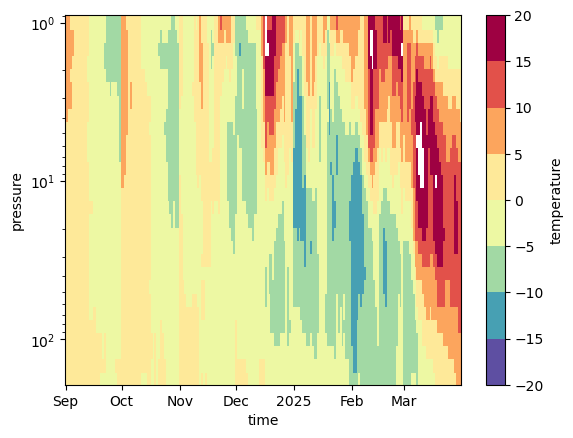

In [25]:
cmap = cm = Colormap('colorbrewer:Spectral_r').to_matplotlib()  # case insensitive
temp.plot(x = 'time', levels = levels, cmap = cmap, yincrease = False, extend = 'neither')
plt.yscale('log')

In [477]:
temp = anom_int[['h2o','O3']].sel(
        latitude_bins = slice(60,None),
        time=slice('2024-10-01','2024-10-30'),
        pressure = slice(pres_start,pres_end),    
    ).weighted(weights).mean('latitude_bins')
temp

<xarray.Dataset> Size: 18kB
Dimensions:    (pressure: 37, time: 30)
Coordinates:
  * pressure   (pressure) float32 148B 177.8 146.8 121.2 ... 0.02154 0.01
  * time       (time) datetime64[ns] 240B 2024-10-01 2024-10-02 ... 2024-10-30
    dayofyear  (time) int64 240B 275 276 277 278 279 280 ... 300 301 302 303 304
Data variables:
    h2o        (time, pressure) float64 9kB nan nan nan nan ... nan nan nan nan
    O3         (time, pressure) float64 9kB 0.02951 0.0345 ... -0.5983 nan

In [494]:
temp.to_netcdf('../O3_H2O_MLS_2024-10.nc')

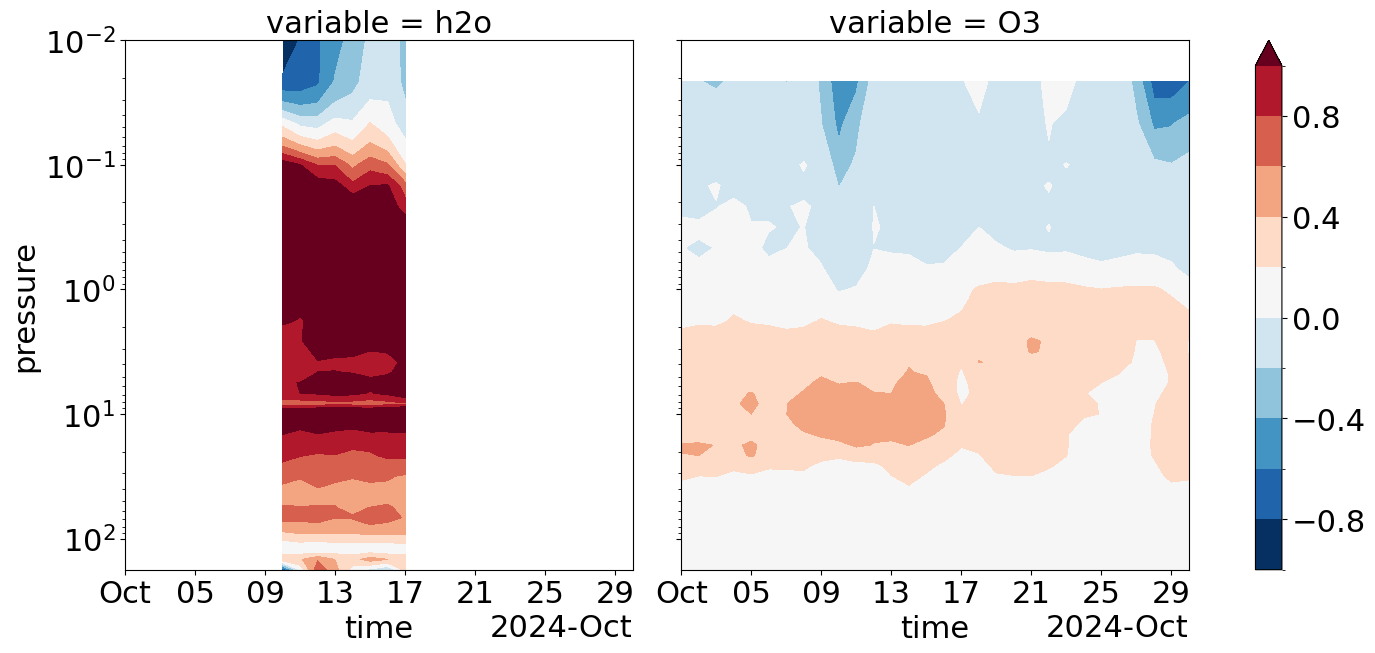

In [484]:
temp.to_array().plot.contourf(y = 'pressure', yincrease = False, col = 'variable', levels = np.arange(-1,1.2,0.2), size = 7)
plt.yscale('log')

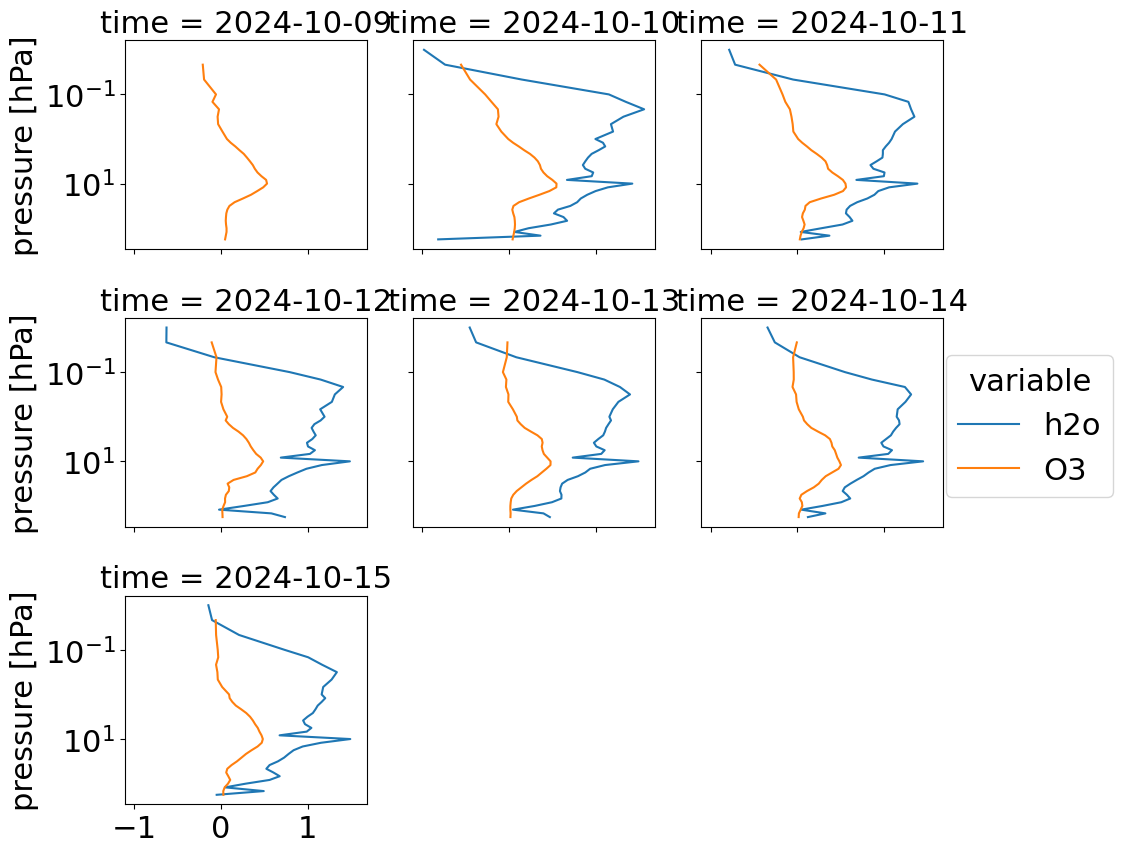

In [497]:
temp.to_array()[:,8:15,:].plot(y = 'pressure', yincrease = False, hue = 'variable', col = 'time', col_wrap = 3)
plt.yscale('log')

In [473]:
temp = anom_mon[['h2o','O3']].sel(
        latitude_bins = slice(60,None),
        time='2024-10-15',
        pressure = slice(pres_start,pres_end),    
    ).weighted(weights).mean('latitude_bins')
temp

<xarray.Dataset> Size: 756B
Dimensions:   (pressure: 37)
Coordinates:
  * pressure  (pressure) float32 148B 177.8 146.8 121.2 ... 0.04642 0.02154 0.01
    time      datetime64[ns] 8B 2024-10-15
    month     int64 8B 10
Data variables:
    h2o       (pressure) float64 296B -0.05214 0.4909 ... -0.1055 -0.1479
    O3        (pressure) float64 296B 0.02518 0.02401 0.03988 ... -0.06296 nan

In [ ]:
anom_int

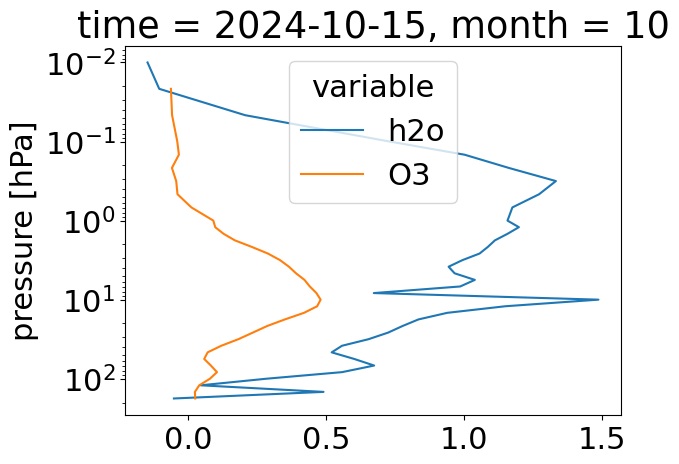

In [474]:
temp.to_array().plot(y = 'pressure', yincrease = False, hue = 'variable')
plt.yscale('log')

TE+WV+O3_time-evolution_2024-10-2025-03_MLS.pdf


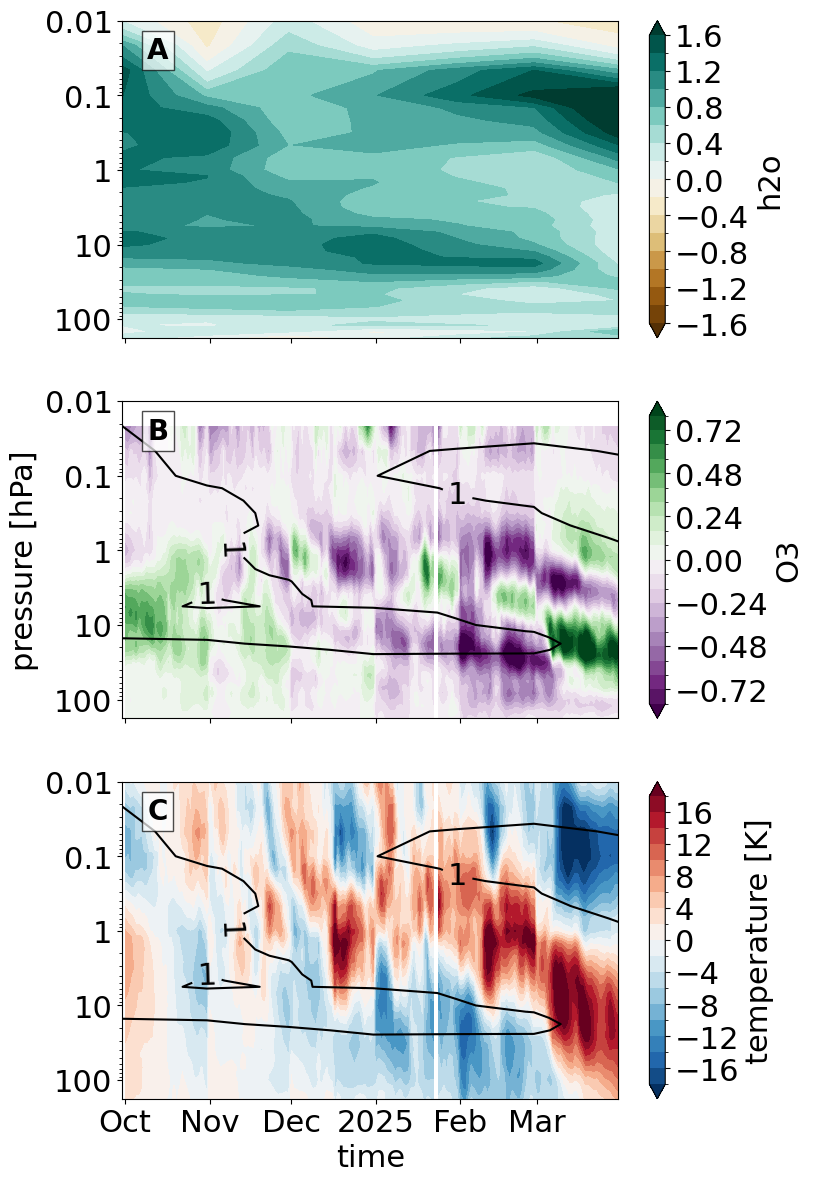

In [32]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(8, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2024
e_year = 2025
s_month = 10
e_month = 3
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]


temp_dict = {}
for i, (sel_var, ax, cmap) in enumerate(zip(sel_var_ls,axes,cmap_ls)):
   
    if sel_var == 'h2o':
        temp = anom_mon[sel_var].sel(
            latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')
        temp = temp.resample(time = '1M').mean().interpolate_na(dim = 'time')
    else:
        temp = anom_mon[sel_var].sel(
            latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')

    temp_dict[sel_var] = temp

    
    p = temp.plot.contourf(
        x = 'time', robust = True, cmap = cmap, 
        yincrease = False, extend = 'both', 
        levels = 21,
        center = 0,
        ax = ax
    )
    if sel_var in ['temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [1],
            colors = ('k'),
            ax = ax
        )
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")

TE+WV+O3_time-evolution_2024-10-2025-03_MLS_anom-int.pdf


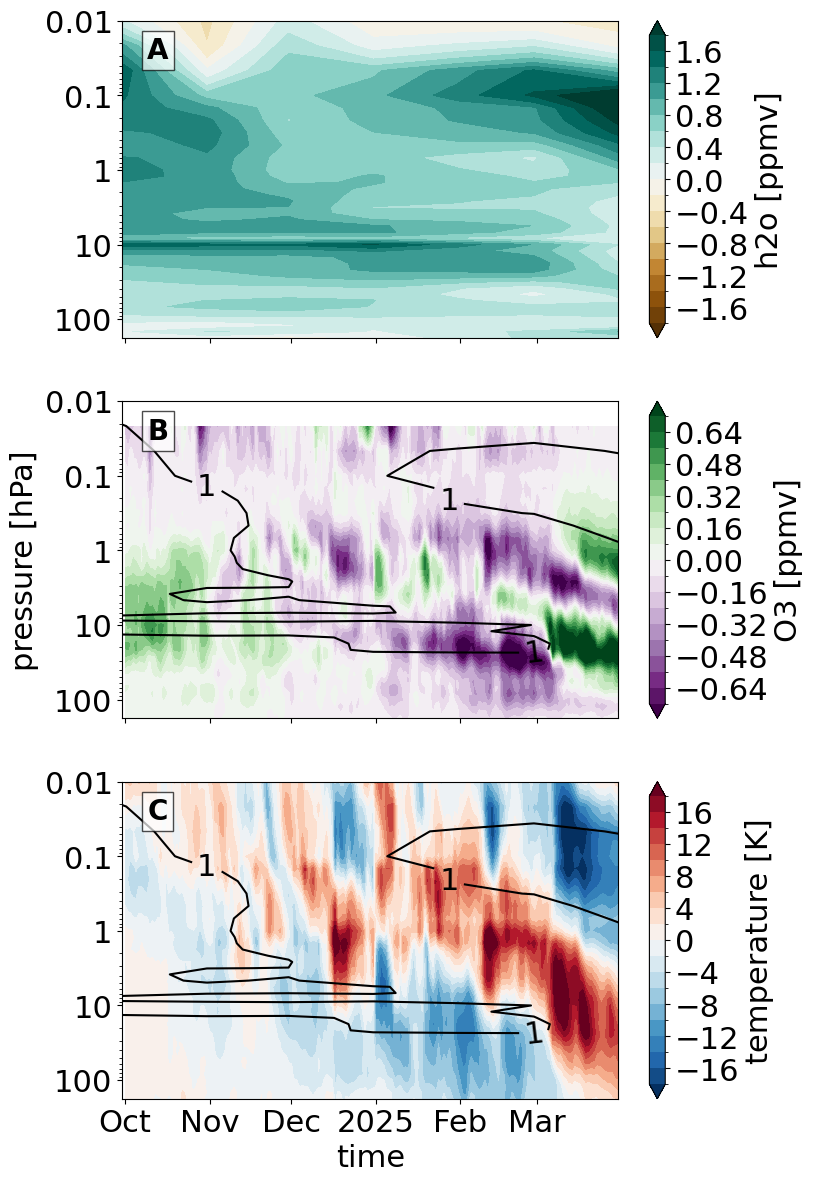

In [83]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(8, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2024
e_year = 2025
s_month = 10
e_month = 3
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]


temp_dict = {}
for i, (sel_var, ax, cmap) in enumerate(zip(sel_var_ls,axes,cmap_ls)):
   
    if sel_var == 'h2o':
        temp = anom_int[sel_var].sel(
            latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')
        temp = temp.resample(time = '1M').mean().interpolate_na(dim = 'time')
    else:
        temp = anom_int[sel_var].sel(
            latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')

    temp_dict[sel_var] = temp

    
    p = temp.plot.contourf(
        x = 'time', robust = True, cmap = cmap, 
        yincrease = False, extend = 'both', 
        levels = 21,
        center = 0,
        ax = ax
    )
    if sel_var in ['temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [1],
            colors = ('k'),
            ax = ax
        )
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS_anom-int.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")

In [12]:
link = 'https://ozonewatch.gsfc.nasa.gov/meteorology/figures/merra2/wind/u60n_10_2024_merra2.txt'
df = pd.read_csv(link, skiprows=6, delim_whitespace=True)
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df

,Data,Minimum,10%,30%,Mean,70%,90%,Maximum
Date,,,,,,,,
2024-07-01,-11.08,-13.76,-13.21,-12.68,-12.07,-11.60,-11.13,-10.28
2024-07-02,-10.76,-13.97,-12.93,-12.44,-12.02,-11.70,-10.84,-10.21
2024-07-03,-11.24,-13.91,-12.79,-12.36,-11.90,-11.43,-10.89,-9.80
2024-07-04,-11.57,-14.28,-13.07,-12.51,-11.97,-11.40,-10.91,-9.51
2024-07-05,-11.60,-13.98,-13.21,-12.43,-11.94,-11.45,-10.86,-9.56
...,...,...,...,...,...,...,...,...
2025-06-26,-9.36,-14.13,-13.30,-12.54,-11.99,-11.38,-10.83,-9.36
2025-06-27,-10.01,-14.27,-13.37,-12.41,-12.00,-11.49,-10.82,-10.01
2025-06-28,-10.08,-14.63,-13.39,-12.61,-12.02,-11.41,-10.76,-10.08


In [18]:
df.to_xarray()

<xarray.Dataset> Size: 26kB
Dimensions:  (Date: 365)
Coordinates:
  * Date     (Date) datetime64[ns] 3kB 2024-07-01 2024-07-02 ... 2025-06-30
Data variables:
    Data     (Date) float64 3kB -11.08 -10.76 -11.24 ... -10.08 -9.84 -10.11
    Minimum  (Date) float64 3kB -13.76 -13.97 -13.91 ... -14.63 -14.09 -13.96
    10%      (Date) float64 3kB -13.21 -12.93 -12.79 ... -13.39 -13.25 -13.05
    30%      (Date) float64 3kB -12.68 -12.44 -12.36 ... -12.61 -12.62 -12.38
    Mean     (Date) float64 3kB -12.07 -12.02 -11.9 ... -12.02 -11.98 -11.96
    70%      (Date) float64 3kB -11.6 -11.7 -11.43 ... -11.41 -11.54 -11.61
    90%      (Date) float64 3kB -11.13 -10.84 -10.89 ... -10.76 -10.67 -10.72
    Maximum  (Date) float64 3kB -10.28 -10.21 -9.8 -9.51 ... -10.08 -9.84 -9.9

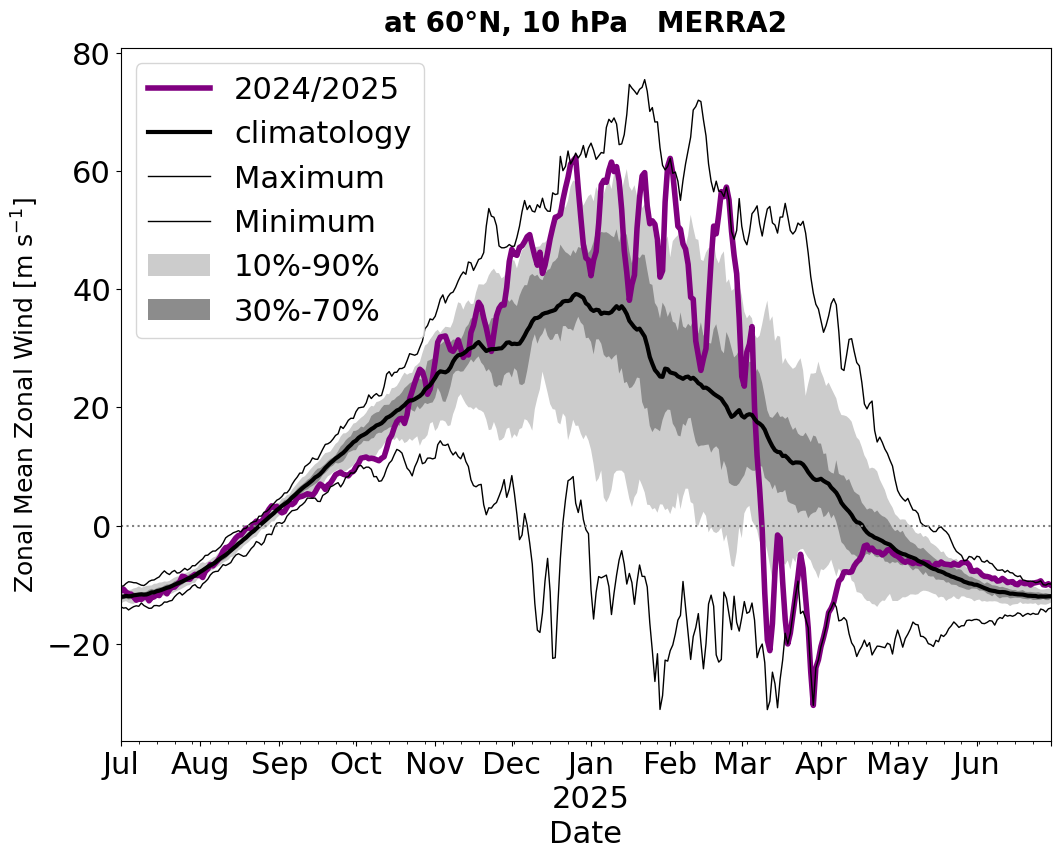

In [13]:
fig, ax = plt.subplots(figsize= (12,9))
x = mdates.date2num(df.index.to_pydatetime())
df['Data'].plot(color = 'purple', ax = ax, lw = 4, label = '2024/2025')
df['Mean'].plot(color = 'k', ax = ax, lw = 3, label = 'climatology')
df['Maximum'].plot(color = 'k', ax = ax, lw = 1)
df['Minimum'].plot(color = 'k', ax = ax, lw = 1)

ax.fill_between(x, df["10%"].to_numpy(), df["90%"].to_numpy(), color="0.80", edgecolor="none", label = '10%-90%')
ax.fill_between(x, df["30%"].to_numpy(), df["70%"].to_numpy(), color="0.55", edgecolor="none", label='30%-70%')

ax.legend()

ax.axhline(0, ls = 'dotted', c = 'gray')
ax.set_ylabel(r"Zonal Mean Zonal Wind [m s$^{-1}$]", fontsize=18)
ax.set_title("at 60°N, 10 hPa   MERRA2", fontsize=20, weight="bold", pad=12)

outfile = 'Fig1A_ZW6010_MERRA2.pdf'
#plt.savefig(outfile,  bbox_inches='tight')

In [104]:
temp

<xarray.DataArray 'h2o' (time: 8, pressure: 37)> Size: 2kB
array([[ 0.74455402,  0.26118264,  0.22752518,  0.35723468,  0.50508555,
         0.62605751,  0.67827884,  0.68175288,  0.68263836,  0.71330823,
         0.78086788,  0.8761829 ,  0.9906264 ,  1.15906926,  1.32671619,
         1.45909062,  1.30546795,  1.33878256,  1.33749161,  1.330093  ,
         1.31822122,  1.33552602,  1.34871827,  1.35157407,  1.37392001,
         1.42031084,  1.45810212,  1.45421954,  1.40742801,  1.36145544,
         1.4107208 ,  1.52390536,  1.60223757,  1.62925537,  1.48948269,
         1.00643919,  0.31938072],
       [ 0.20760341,  0.24218224,  0.24360478,  0.37686661,  0.54565372,
         0.67677995,  0.70420861,  0.69129912,  0.70675266,  0.76816406,
         0.85701292,  0.95415746,  1.05662478,  1.19933104,  1.32216898,
         1.38869109,  1.1964929 ,  1.20345592,  1.19976579,  1.19063906,
         1.17499641,  1.20208519,  1.24871838,  1.28638512,  1.31833321,
         1.34999774,  1.37484235,  1.39188258,  1.43011958,  1.49382729,
         1.52434432,  1.45025034,  1.21699325,  0.82110081,  0.30474413,
        -0.10332992, -0.27351805],
       [-0.42577349,  0.13380119,  0.2917996 ,  0.4385826 ,  0.60920845,
         0.74390568,  0.7516207 ,  0.70489051,  0.72300881,  0.83324545,
         0.968596  ,  1.06542655,  1.12681008,  1.22200655,  1.3119977 ,
         1.36008513,  1.16127152,  1.19068828,  1.21933085,  1.22415491,
...
         0.77479957,  0.71871094,  0.70481205,  0.71902913,  0.7281315 ,
         0.70652763,  0.64547321,  0.59290031,  0.61767615,  0.83588019,
         1.10223428,  1.33817359,  1.52479826,  1.6336805 ,  1.33977037,
         0.65102651,  0.06590497],
       [ 0.15885374,  0.56082958,  0.45986311,  0.46486251,  0.51533668,
         0.54300113,  0.53005403,  0.58412942,  0.6928985 ,  0.74367381,
         0.69181613,  0.59147323,  0.49669734,  0.43294583,  0.39655551,
         0.39764015,  0.36180547,  0.38505401,  0.39026169,  0.38099948,
         0.36760483,  0.38020736,  0.42640614,  0.50566704,  0.60747752,
         0.71344126,  0.83796836,  1.02353108,  1.32047322,  1.64519152,
         1.97445677,  2.24880346,  2.34119504,  2.06229297,  1.19696278,
         0.33277043, -0.14357595],
       [-0.50287968,  0.45744963,  0.42845105,  0.43228392,  0.50622327,
         0.56868208,  0.54622307,  0.54185424,  0.59453303,  0.64749594,
         0.64656395,  0.60068494,  0.551761  ,  0.53680777,  0.52524017,
         0.49791934,  0.37197381,  0.35865213,  0.37178391,  0.41295552,
         0.44939532,  0.47806056,  0.50565224,  0.56307821,  0.66045606,
         0.77423084,  0.89717163,  1.05499211,  1.26974964,  1.50089383,
         1.77788096,  2.00041053,  1.99886334,  1.53508148,  0.47192321,
        -0.4709691 , -0.80871227]])
Coordinates:
  * pressure  (pressure) float32 148B 177.8 146.8 121.2 ... 0.04642 0.02154 0.01
  * time      (time) datetime64[ns] 64B 2024-09-30 2024-10-31 ... 2025-04-30
    month     (time) int64 64B 9 10 11 12 1 2 3 4
Attributes:
    long_name:  water vapour VMR from MLS
    units:      ppmv

In [111]:
pres_start=200
pres_end = 0.01
s_year = 2024
e_year = 2026
s_month = 9
e_month = 4
time_start = f'{s_year}-{s_month-1:02d}'
time_end =  f'{e_year}-{e_month:02d}'

weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"

temp = h2o_anom_int_mon.sel(
            latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')
temp = temp.interpolate_na(dim = 'time')
temp.attrs['long_name'] = 'water vapour VMR from MLS'
temp.attrs['units'] = 'ppmv'

In [115]:
p.axes

<Axes: xlabel='time', ylabel='pressure [hPa]'>

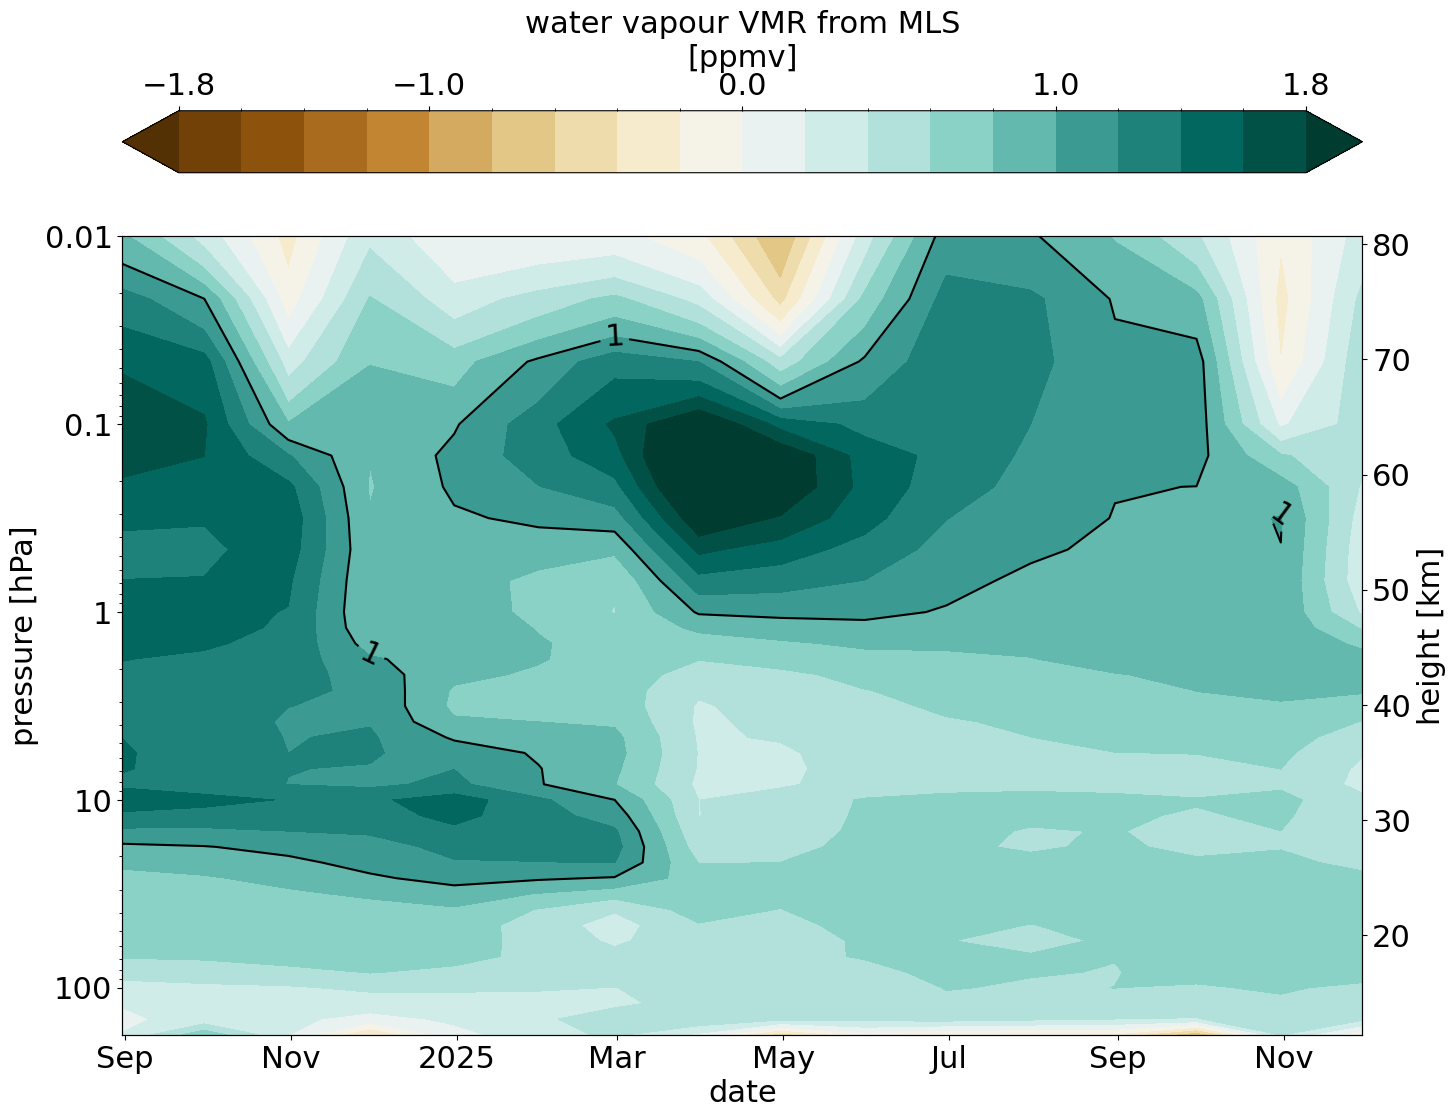

In [124]:
p = temp.plot.contourf(
        x = 'time', robust = True, cmap = 'BrBG', 
        yincrease = False, extend = 'both', 
        levels = np.arange(-1.8,2,0.2),
        size= 12,
        cbar_kwargs = dict(ticks = [-1.8,-1,0,1,1.8], location = 'top', pad = 0.05, fraction=0.086, anchor = (0,1))
    )

ax = p.axes
ax.set_yscale('log')

CS = temp.plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [1],
            colors = ('k'),
            ax = ax
        )
ax.clabel(CS)
ax.set_yscale('log')
fmt = mpl.ticker.FormatStrFormatter("%g")
ax.yaxis.set_major_formatter(fmt)
ax.set_xlabel('date')

ax2 = ax.twinx()
ax2.get_shared_y_axes()
#ax2.axis([lat_start, 90, 7*np.log(1013.25/plev_start), 7*np.log(1013.25/plev_end)])
ax2.set_ylim( 7*np.log(1013.25/pres_start), 7*np.log(1013.25/pres_end))
#ax2.tick_params(direction='out', which='both', labelsize=18)#, pad = 50)
ax2.set_ylabel('height [km]')

outfile = f'WV_MLS_{time_start}--{time_end}.png'
plt.savefig(outfile, bbox_inches = 'tight')

In [127]:
np.linspace(1, 3, 5)

array([1. , 1.5, 2. , 2.5, 3. ])

In [125]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

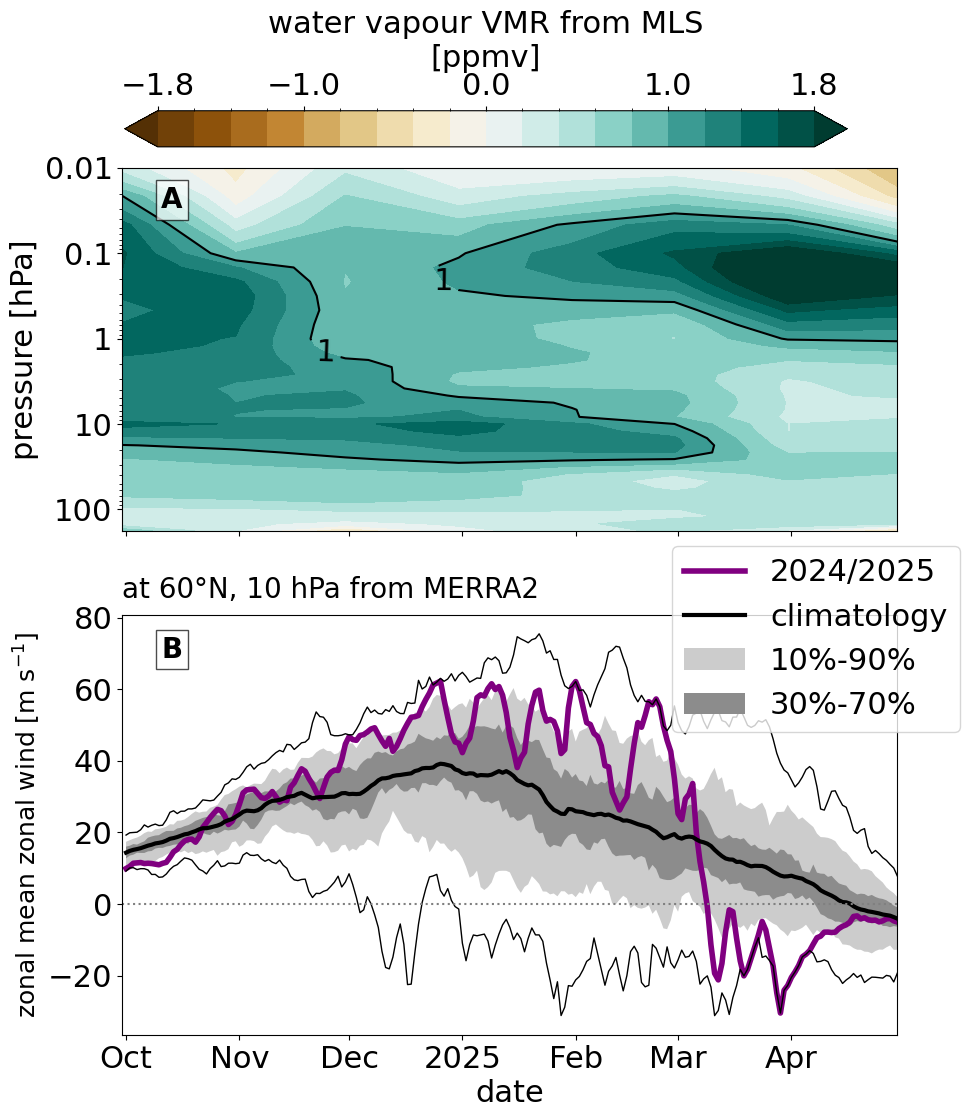

In [101]:
pres_start=200
pres_end = 0.01
s_year = 2024
e_year = 2025
s_month = 10
e_month = 4
time_start = f'{s_year}-{s_month-1:02d}'
time_end =  f'{e_year}-{e_month:02d}'

weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"

temp = h2o_anom_int_mon.sel(
            latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')
temp = temp.interpolate_na(dim = 'time')
temp.attrs['long_name'] = 'water vapour VMR from MLS'
temp.attrs['units'] = 'ppmv'

f, axes = plt.subplots(2, 1, figsize=(10, 12), sharex =True)
ax = axes[0]
p = temp.plot.contourf(
        x = 'time', robust = True, cmap = 'BrBG', 
        yincrease = False, extend = 'both', 
        levels = np.arange(-1.8,2,0.2),
        ax = ax, cbar_kwargs = dict(ticks = [-1.8,-1,0,1,1.8], location = 'top', pad = 0.05, fraction=0.086, anchor = (0,1))
    )
#p.colorbar.set_ylabel('Test', x = 1.5, y = 1)
CS = temp.plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [1],
            colors = ('k'),
            ax = ax
        )
ax.clabel(CS)


ax.set_yscale('log')
fmt = mpl.ticker.FormatStrFormatter("%g")
ax.yaxis.set_major_formatter(fmt)
ax.set_xlabel('')
# second row
ax = axes[1]
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'
df_x = df.to_xarray().sel(Date = slice(time_start, time_end))
df_x['Data'].plot(color = 'purple', ax = ax, lw = 4, label = '2024/2025')
df_x['Mean'].plot(color = 'k', ax = ax, lw = 3, label = 'climatology')
df_x['Maximum'].plot(color = 'k', ax = ax, lw = 1)
df_x['Minimum'].plot(color = 'k', ax = ax, lw = 1)

x = mdates.date2num(df_x.Date.to_index())
ax.fill_between(x, df_x["10%"].to_numpy(), df_x["90%"].to_numpy(), color="0.80", edgecolor="none", label = '10%-90%')
ax.fill_between(x, df_x["30%"].to_numpy(), df_x["70%"].to_numpy(), color="0.55", edgecolor="none", label='30%-70%')

ax.legend(loc = 'upper right', bbox_to_anchor = (1.1,1.2))


ax.axhline(0, ls = 'dotted', c = 'gray')
ax.set_ylabel(r"zonal mean zonal wind [m s$^{-1}$]", fontsize=18)
ax.set_title("at 60°N, 10 hPa from MERRA2", fontsize=20,  pad=12, loc = 'left')
ax.set_xlabel('date')

for i,ax in enumerate(axes):
    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )

outfile = 'WV_MLS+ZW_MERRA.png'
plt.savefig(outfile, bbox_inches = 'tight')


In [102]:
from run_webdav_boku import run_client

client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

In [103]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

# asdasds

h2o 1.7999999999999992
O3 0.9999999999999996
temperature 18.0
TE+WV+O3_time-evolution_2024-10-2025-03_MLSv6_anom-int2.pdf


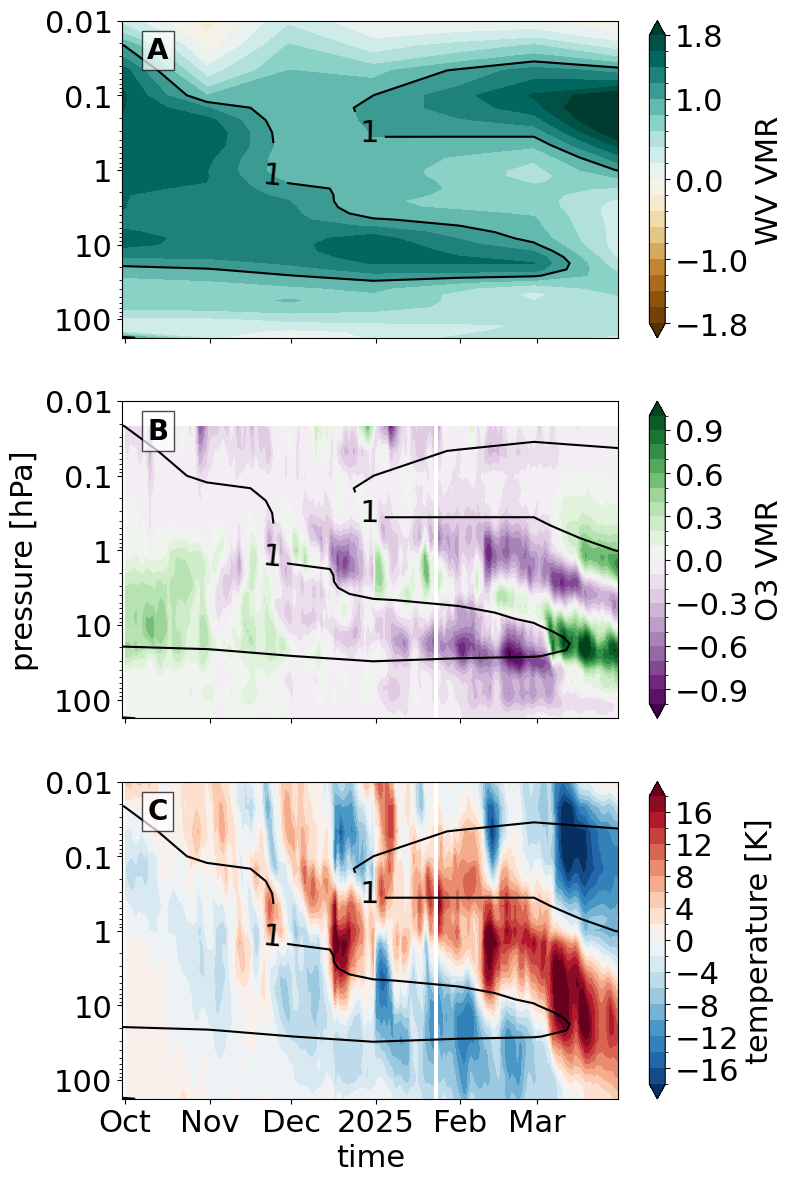

In [14]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(8, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2024
e_year = 2025
s_month = 10
e_month = 3
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]
long_name_ls = ['WV VMR', 'O3 VMR', 'temperature']


temp_dict = {}
for i, (sel_var, ax, cmap, long_name) in enumerate(zip(sel_var_ls,axes,cmap_ls, long_name_ls)):
   
    if sel_var == 'h2o':
        temp = h2o_anom_int_mon.sel(
            latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')
        temp = temp.interpolate_na(dim = 'time')
    else:
        temp = anom_int[sel_var].sel(
            latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')

    temp.attrs['long_name'] = long_name
    temp_dict[sel_var] = temp

    if sel_var == 'O3':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1,1.1,0.1),
            ax = ax, 
        )
    elif sel_var == 'h2o':
         p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1.8,2,0.2),
            ax = ax, cbar_kwargs = dict(ticks = [-1.8,-1,0,1,1.8])
        )
    else:
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-18,20,2),#21,
            center = 0,
            ax = ax
        )
    print(sel_var, p.colorbar.vmax)
    if sel_var in ['h2o','temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [1],
            colors = ('k'),
            ax = ax
        )
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS{msl_suffix}_anom-int2.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")

In [34]:
from run_webdav_boku import run_client

client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")

True

In [35]:
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)

h2o 1.8
O3 0.9999999999999996
temperature 18.0
TE+WV+O3_time-evolution_2024-10-2025-03_MLS_anom.pdf


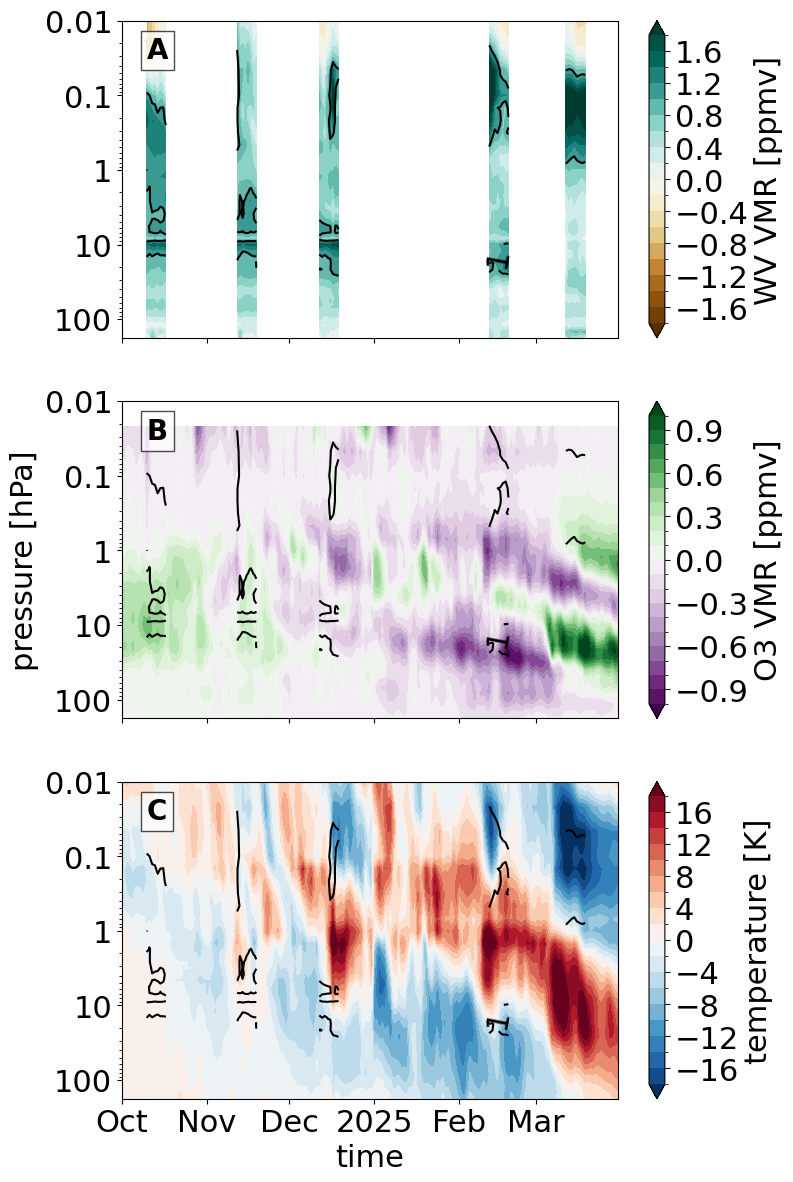

In [24]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(8, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2024
e_year = 2025
s_month = 10
e_month = 3
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]
long_name_ls = ['WV VMR', 'O3 VMR', 'temperature']

temp_dict = {}
for i, (sel_var, ax, cmap, long_name) in enumerate(zip(sel_var_ls,axes,cmap_ls, long_name_ls)):
   
    if sel_var == 'h2o2':
        temp = h2o_anom_int_mon.sel(
            latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')
        temp = temp.interpolate_na(dim = 'time')
    else:
        temp = anom_int[sel_var].sel(
            latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')

    temp.attrs['long_name'] = long_name
    temp_dict[sel_var] = temp

    if sel_var == 'O3':
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = np.arange(-1,1.1,0.1),
            ax = ax
        )
    else:
        p = temp.plot.contourf(
            x = 'time', robust = True, cmap = cmap, 
            yincrease = False, extend = 'both', 
            levels = 21,
            center = 0,
            ax = ax
        )
    print(sel_var, p.colorbar.vmax)
    if sel_var in ['h2o','temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [1],
            colors = ('k'),
            ax = ax
        )
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS_anom.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")

TE+WV+O3_time-evolution_2024-10-2025-03_MLS.pdf


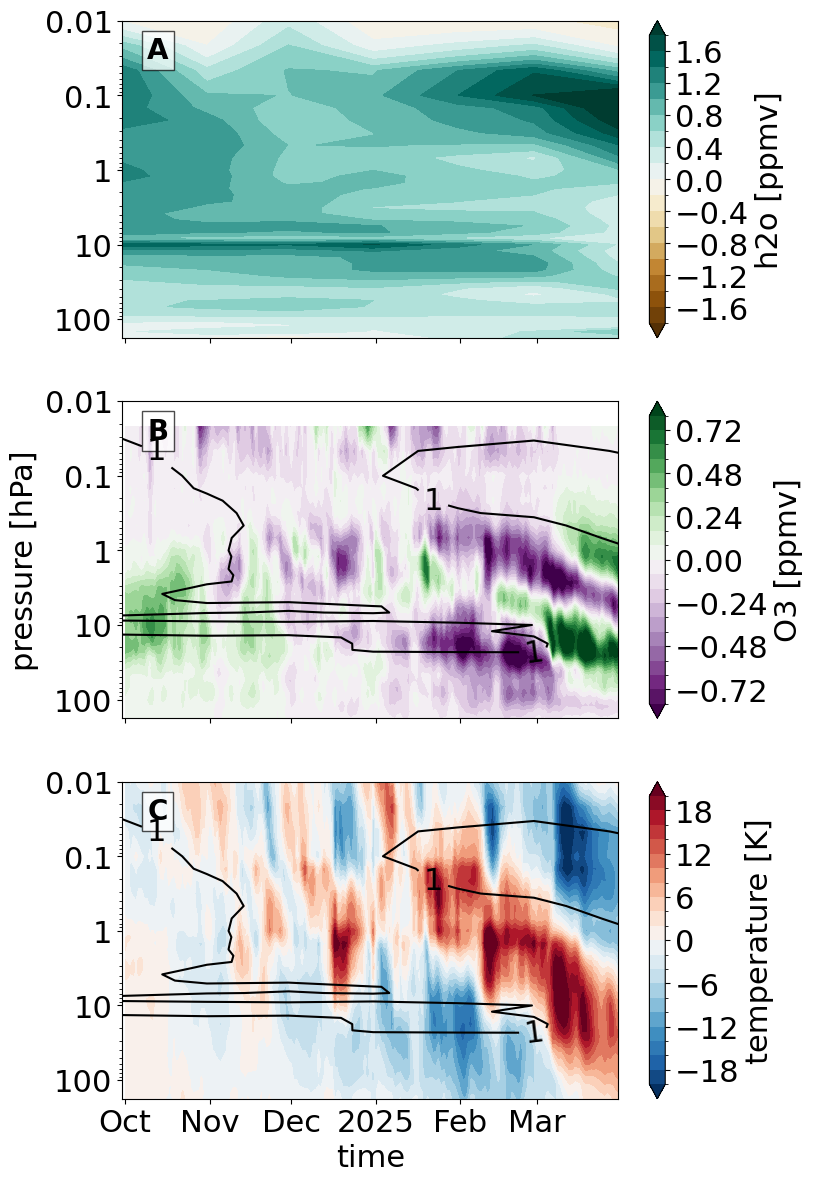

In [37]:
n_rows = 3
f, axes = plt.subplots(n_rows, 1, figsize=(8, 14), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=200
pres_end = 0.01
s_year = 2024
e_year = 2025
s_month = 10
e_month = 3
time_start = f'{s_year}-{s_month:02d}'
time_end =  f'{e_year}-{e_month:02d}'

sel_var_ls = ['h2o','O3','temperature',]
cmap_ls = ['BrBG',"PRGn",'RdBu_r',]


temp_dict = {}
for i, (sel_var, ax, cmap) in enumerate(zip(sel_var_ls,axes,cmap_ls)):
   
    if sel_var == 'h2o':
        temp = anom_doy[sel_var].sel(
            latitude_bins = slice(60,None),
            time = slice(f'{s_year}-{s_month-1:02d}', time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')
        temp = temp.resample(time = '1M').mean().interpolate_na(dim = 'time')
    else:
        temp = anom_doy[sel_var].sel(
            latitude_bins = slice(60,None),
            time = slice(time_start, time_end),
            pressure = slice(pres_start,pres_end),    
        ).weighted(weights).mean('latitude_bins')

    temp_dict[sel_var] = temp

    
    p = temp.plot.contourf(
        x = 'time', robust = True, cmap = cmap, 
        yincrease = False, extend = 'both', 
        levels = 21,
        center = 0,
        ax = ax
    )
    if sel_var in ['temperature','O3']:
        CS = temp_dict['h2o'].plot.contour(
            x = 'time', 
            yincrease = False, add_colorbar = False, 
            levels = [1],
            colors = ('k'),
            ax = ax
        )
        ax.clabel(CS)
    
    ax.set_yscale('log')
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    if i != n_rows-1:
        ax.set_xlabel('')

    if i != 1:
        ax.set_ylabel('')

    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )


outfile = f"TE+WV+O3_time-evolution_{time_start}-{time_end}_MLS.pdf"
print(outfile)
#plt.savefig(outfile, bbox_inches="tight")

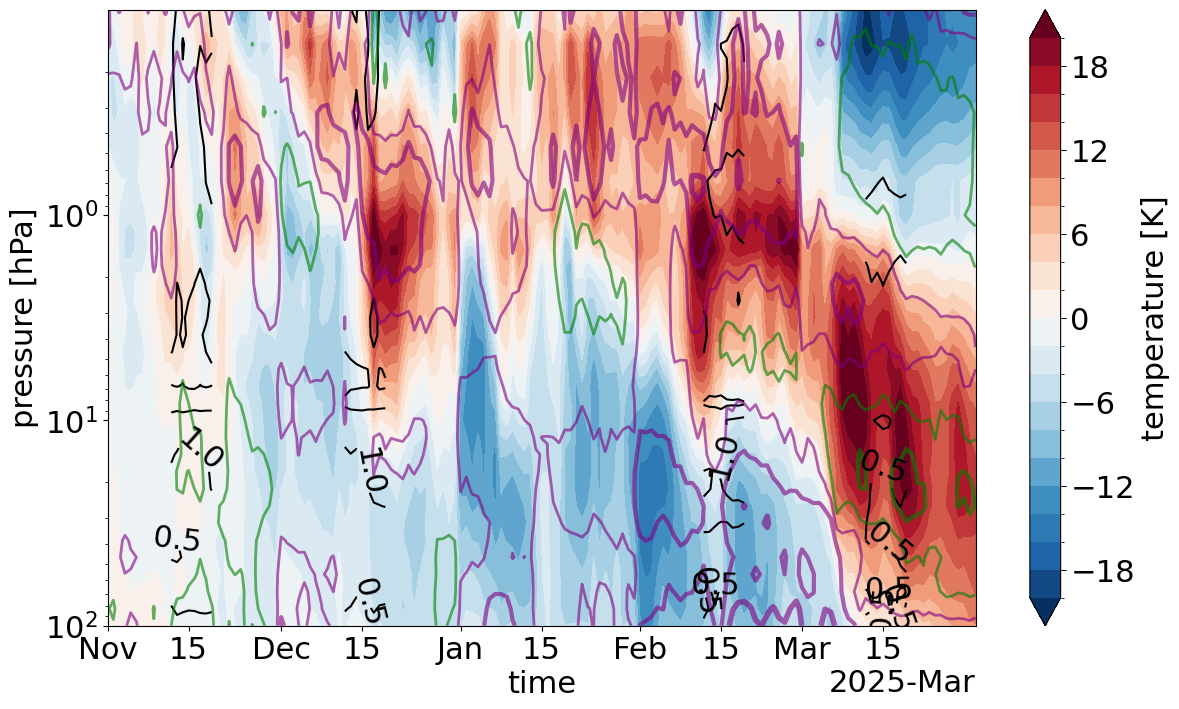

In [91]:
n_rows = 1
f, ax = plt.subplots(n_rows, 1, figsize=(14, 8), sharex =True)
weights = np.cos(np.deg2rad(ds.latitude_bins))
weights.name = "weights"
pres_start=100
pres_end = 0.1
time_start = '2024-11'
time_end = '2025-03'

sel_var_ls = ['temperature','h2o','O3']
cmap_ls = ['RdBu_r','BrBG',"PRGn"]


    
temp = anom['temperature'].sel(
    latitude_bins = slice(60,None),
    time = slice(time_start, time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')

p = temp.plot.contourf(x = 'time', levels=np.linspace(-20,20,21), cmap = cmap_ls[0], yincrease = False, extend = 'both', ax = ax)


temp = anom['h2o'].sel(
    latitude_bins = slice(60,None),
    time = slice(time_start, time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')

#p = temp.plot.contour(x = 'time', robust = True, cmap = cmap_ls[0], yincrease = False, extend = 'both', ax = ax)
temp.plot.contour(x = 'time', yincrease = False, levels=[0], extend = 'both', colors = ('k'), linewidths=3, ax = ax)
CS = temp.plot.contour(x = 'time', yincrease = False, levels=[0.5, 1, 3], extend = 'both', colors = ('k'), ax = ax)
ax.clabel(CS)

ozone_perc = anom['O3']/ds['O3']*100
temp = ozone_perc.sel(
    latitude_bins = slice(60,None),
    time = slice(time_start, time_end),
    pressure = slice(pres_start,pres_end),    
).weighted(weights).mean('latitude_bins')

#p = temp.plot.contour(x = 'time', robust = True, colors = ('k'), yincrease = False, extend = 'both', ax = ax)
temp.plot.contour(x = 'time', yincrease = False, levels=[-30, -15, -5], extend = 'both', colors = ('purple','purple','purple'), ax = ax, linewidths=np.linspace(4, 2, 3), alpha = 0.6)

temp.plot.contour(x = 'time', yincrease = False, levels=[5, 15, 30], extend = 'both', colors = ('green','green','green'), ax = ax, linewidths=np.linspace(2, 4, 3), alpha = 0.6)






ax.set_yscale('log')

        